## g1/g2 extraction test without depending on coordinate axis

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Step 3: Single-layer grain/GB selection in a *local* frame.

This version does NOT rely on cartesian x/y/z from Step 1.
Instead it:

  1) Computes a slab normal n_slab from the geometry of the slab.
  2) Computes a GB normal n_gb (inside the slab plane) from the GB residues.
  3) Builds an orthonormal basis (t, n_gb, n_slab) where:
         s = COM · n_slab     (slab-normal coordinate)
         g = COM · n_gb       (GB-normal coordinate in the slab plane)
         m = COM · t          (transverse coordinate along the GB)

  4) Selects a single mid-layer along s (slab_thick).
  5) Within that layer, segments GB resids into connected components,
     defines a GB band around each segment at g ≈ y0, and defines
     grain bands at offset ±gb_offset along g.
  6) Within each grain band, picks the largest connected component,
     optionally capped at target_per_side using BFS from the centroid.

The output API (rows list, fields) is kept compatible with the main pipeline,
except that `gb_axis` is now just a label passed through (the true geometry
is in the local frame described above).
"""

from __future__ import annotations

import logging
import re
from collections import deque
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
from sklearn.neighbors import NearestNeighbors

from src.utils import (
    margin_mask_1d,
    write_gro_for_resids,
    connected_components,
)

logger = logging.getLogger(__name__)

__all__ = ["step3_single_layer_for_slab"]

# -------------------------
# Local helpers
# -------------------------


def largest_component_within(
    idxs: np.ndarray | List[int],
    COM: np.ndarray,
    radius: float,
) -> np.ndarray:
    """
    Return indices of the largest connected component within `idxs`.
    Uses COM distances with a given neighbor radius.
    """
    idxs = np.asarray(idxs, dtype=int)
    if idxs.size == 0:
        return np.array([], dtype=int)

    comps = connected_components(COM, radius, subset_idx=idxs)
    if not comps:
        return np.array([], dtype=int)

    comps.sort(key=len, reverse=True)
    return comps[0]


def cap_component(
    ids: np.ndarray | List[int],
    target: Optional[int],
    COM: np.ndarray,
    radius: float,
) -> np.ndarray:
    """
    Cap a connected component to at most `target` elements by BFS from centroid.

    If target is None or component is already smaller than target,
    return `ids` unchanged.
    """
    ids = np.asarray(ids, dtype=int)
    if target is None or ids.size == 0 or ids.size <= target:
        return ids

    sub = ids
    nbr_local = NearestNeighbors(radius=radius).fit(COM[sub])
    G = nbr_local.radius_neighbors_graph(COM[sub], mode="connectivity")

    ctr = COM[sub].mean(axis=0)
    seed = int(np.argmin(np.linalg.norm(COM[sub] - ctr, axis=1)))

    seen = np.zeros(len(sub), dtype=bool)
    seen[seed] = True
    sel = [seed]
    q: deque[int] = deque([seed])

    while q and len(sel) < target:
        i = q.popleft()
        for j in G[i].indices:
            if not seen[j]:
                seen[j] = True
                q.append(j)
                sel.append(j)
                if len(sel) >= target:
                    break

    return sub[np.array(sel, dtype=int)]


def _load_anysep(path: str | Path) -> set[int]:
    """
    Load integers from a text file with arbitrary separators. Returns a set of ints.
    """
    path = Path(path)
    s: set[int] = set()
    with path.open() as f:
        for line in f:
            for tok in re.findall(r"-?\d+", line):
                s.add(int(tok))
    return s


def _valid_resids(path: str | Path, resid_to_idx: Dict[int, int]) -> List[int]:
    """Filter loaded resids to those present in `resid_to_idx`."""
    resids = _load_anysep(path)
    return sorted(r for r in resids if r in resid_to_idx)


def _pca_frame_from_points(points: np.ndarray) -> np.ndarray:
    """
    PCA on a set of 3D points.

    Returns a 3x3 matrix whose columns are eigenvectors corresponding
    to ascending eigenvalues (smallest variance first).
    """
    pts = np.asarray(points, float)
    if pts.shape[0] < 3:
        # Not enough points for a stable PCA; fall back to identity.
        return np.eye(3)

    ctr = pts.mean(axis=0)
    X = pts - ctr
    cov = np.cov(X.T)
    vals, vecs = np.linalg.eigh(cov)  # eigenvalues ascending
    order = np.argsort(vals)          # explicit, though eigh already returns sorted
    vecs = vecs[:, order]             # columns: v0 (min var), v1, v2 (max var)
    return vecs


def _compute_local_frame(COM: np.ndarray, gb_idx_all: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute an orthonormal basis (t, n_gb, n_slab) for the slab.

    - n_slab : slab normal (smallest variance direction)
    - n_gb   : GB-normal direction in the slab plane (intermediate variance)
    - t      : transverse direction along the GB (largest variance)

    We primarily use GB residues to define this frame. If GB is too small,
    we fall back to all COMs.

    Also prints how these three axes are aligned:
      * pairwise angles between (n_slab, n_gb, t)
      * angles w.r.t. lab frame axes (x, y, z).
    """
    if gb_idx_all.size >= 10:
        pts = COM[gb_idx_all]
        frame = _pca_frame_from_points(pts)
        logger.info("STEP3: using %d GB residues for PCA frame.", gb_idx_all.size)
    else:
        logger.warning(
            "STEP3: Not enough GB residues (%d) for stable PCA; using all COMs.",
            gb_idx_all.size,
        )
        frame = _pca_frame_from_points(COM)

    # columns: v0 (min var), v1, v2 (max var)
    v0 = frame[:, 0]  # slab normal candidate
    v1 = frame[:, 1]  # GB-normal candidate
    v2 = frame[:, 2]  # GB tangent candidate

    # Normalize (eigh should already give unit vectors, but be safe)
    n_slab = v0 / np.linalg.norm(v0)
    n_gb_raw = v1 / np.linalg.norm(v1)

    # enforce n_gb in slab plane
    n_gb = n_gb_raw - np.dot(n_gb_raw, n_slab) * n_slab
    n_gb /= np.linalg.norm(n_gb)

    t = np.cross(n_slab, n_gb)
    t /= np.linalg.norm(t)

    # ------------ Debug prints: alignment ------------
    def _angle(u: np.ndarray, v: np.ndarray) -> float:
        u = u / np.linalg.norm(u)
        v = v / np.linalg.norm(v)
        cosang = float(np.clip(np.dot(u, v), -1.0, 1.0))
        return float(np.degrees(np.arccos(cosang)))

    # round for compact printing
    n_slab_r = np.round(n_slab, 4)
    n_gb_r   = np.round(n_gb, 4)
    t_r      = np.round(t, 4)

    print("\n[STEP3 frame] Local orthonormal basis (lab coordinates):")
    print(f"  n_slab (slab normal)     = {n_slab_r}")
    print(f"  n_gb   (GB normal inplane)= {n_gb_r}")
    print(f"  t      (along GB)        = {t_r}")

    print("[STEP3 frame] Pairwise angles between axes (deg):")
    print(f"  angle(n_slab, n_gb) = {_angle(n_slab, n_gb):6.2f}")
    print(f"  angle(n_slab, t)    = {_angle(n_slab, t):6.2f}")
    print(f"  angle(n_gb,   t)    = {_angle(n_gb,   t):6.2f}")

    # vs lab-frame x,y,z (helps see if slab is 'almost z', etc.)
    ex = np.array([1.0, 0.0, 0.0])
    ey = np.array([0.0, 1.0, 0.0])
    ez = np.array([0.0, 0.0, 1.0])

    print("[STEP3 frame] Angles to lab (x,y,z) in degrees:")
    print(
        "  n_slab vs (x,y,z) = "
        f"{_angle(n_slab, ex):6.2f}, {_angle(n_slab, ey):6.2f}, {_angle(n_slab, ez):6.2f}"
    )
    print(
        "  n_gb   vs (x,y,z) = "
        f"{_angle(n_gb, ex):6.2f}, {_angle(n_gb, ey):6.2f}, {_angle(n_gb, ez):6.2f}"
    )
    print(
        "  t      vs (x,y,z) = "
        f"{_angle(t, ex):6.2f}, {_angle(t, ey):6.2f}, {_angle(t, ez):6.2f}"
    )
    print("-" * 72)

    return t, n_gb, n_slab



# -------------------------
# Step 3 — Single-layer grain/GB selection in local frame
# -------------------------


def step3_single_layer_for_slab(
    slab_gro: str | Path,
    slab_dir: str | Path,
    step2_out: Dict[str, object],
    gb_axis: str,
    a_len: float,
    b_len: float,
    c_len: float,
    alpha: float,
    beta: float,
    gamma: float,
    slab_thick: float,
    gb_offset: float,
    gb_band_thick: float,
    box_margin: float,
    connect_radius_layer: float,
    write_txt: bool,
    write_gro: bool,
    min_count_write: int,      # kept for interface parity; unused
    min_gb_to_write: int,
    target_per_side: Optional[int],
    slab_axis: str,            # kept for interface parity; ignored
) -> List[dict]:
    """
    Select a single mid-layer and partition it into GB / grain1 / grain2
    bands using a *local* geometric frame.

    The local frame is constructed as follows:

      - Use GB residue COMs to perform PCA.
      - Smallest-variance eigenvector -> slab normal n_slab.
      - Second eigenvector -> GB-normal direction n_gb in the slab plane.
      - Third eigenvector -> transverse direction t along the GB.

    For each residue i with COM r_i, define:

      s_i = r_i · n_slab    (slab-normal coordinate)
      g_i = r_i · n_gb      (GB-normal coordinate)
      m_i = r_i · t         (transverse coordinate)

    Then:

      - Select a mid-layer in s_i with thickness slab_thick.
      - Within that layer, segment GB into connected components.
      - For each GB segment, define:
          * GB band: |g - y0| <= gb_band_thick/2
          * Grain bands:
              g in [y0 - (gb_offset + gb_band_thick), y0 - gb_offset]
              or   [y0 + gb_offset, y0 + (gb_offset + gb_band_thick)]
      - Within grain bands, pick the largest connected component;
        optionally cap to target_per_side molecules.

    Returns a list of dict rows compatible with the main workflow.
    """
    slab_gro = Path(slab_gro)
    slab_dir = Path(slab_dir)

    # universe / coordinates
    u = step2_out["u"]
    residues = list(u.residues)

    resid_to_idx: Dict[int, int] = {r.resid: i for i, r in enumerate(residues)}
    idx_to_resid: Dict[int, int] = {i: r.resid for i, r in enumerate(residues)}

    # COMs in lab frame (Å)
    COM = np.array([r.atoms.center_of_mass() for r in residues])

    # --- load grain / GB resids from Step 2 paths ---
    paths = step2_out["paths"]
    G1_resids = _valid_resids(paths["g1"], resid_to_idx)
    G2_resids = _valid_resids(paths["g2"], resid_to_idx)
    GB_resids = _valid_resids(paths["gb"], resid_to_idx)

    g1_idx_all = np.array([resid_to_idx[r] for r in G1_resids], dtype=int)
    g2_idx_all = np.array([resid_to_idx[r] for r in G2_resids], dtype=int)
    gb_idx_all = np.array([resid_to_idx[r] for r in GB_resids], dtype=int)

    if gb_idx_all.size == 0:
        logger.warning("STEP3: No GB residues found for %s; returning empty rows.", slab_gro.name)
        return []

    # --- construct local frame (t, n_gb, n_slab) from GB geometry ---
    t, n_gb, n_slab = _compute_local_frame(COM, gb_idx_all)

    # project COMs into local coordinates
    s_coord = COM @ n_slab   # slab-normal
    g_coord = COM @ n_gb     # GB-normal (in-plane)
    m_coord = COM @ t        # transverse

    # mid-layer along slab-normal
    s_min, s_max = float(s_coord.min()), float(s_coord.max())
    slab_center = 0.5 * (s_min + s_max)
    layer_mask_this = np.abs(s_coord - slab_center) <= slab_thick / 2.0

    # margin in transverse direction: keep only central band in m_coord
    margin_mask_axis = margin_mask_1d(m_coord, box_margin)

    logger.info(
        "[step3-single-local] %s: s_range=(%.2f, %.2f), center=%.2f, slab_thick=%.2f",
        slab_gro.name,
        s_min,
        s_max,
        slab_center,
        slab_thick,
    )

    # -----------------------
    # Segment GB within mid-layer
    # -----------------------
    gb_idx_layer = gb_idx_all[layer_mask_this[gb_idx_all] & margin_mask_axis[gb_idx_all]]

    if gb_idx_layer.size:
        nbrs = NearestNeighbors(radius=connect_radius_layer).fit(COM[gb_idx_layer])
        G = nbrs.radius_neighbors_graph(COM[gb_idx_layer], mode="connectivity")
        seen = np.zeros(len(gb_idx_layer), dtype=bool)
        comps: List[np.ndarray] = []

        for s0 in range(len(gb_idx_layer)):
            if seen[s0]:
                continue
            q: deque[int] = deque([s0])
            seen[s0] = True
            cur: List[int] = [s0]
            while q:
                i = q.popleft()
                for j in G[i].indices:
                    if not seen[j]:
                        seen[j] = True
                        q.append(j)
                        cur.append(j)
            comps.append(np.array(cur, dtype=int))

        gb_segments = [gb_idx_layer[c] for c in comps]
    else:
        gb_segments = []

    slab_stem = slab_gro.stem
    rows: List[dict] = []
    seg_id = 0

    # for ranking: box "center" along GB normal in local frame
    g_min, g_max = float(g_coord.min()), float(g_coord.max())
    g_mid = 0.5 * (g_min + g_max)

    for seg in sorted(gb_segments, key=len, reverse=True):
        seg_id += 1

        # GB center along g
        y0 = float(np.median(g_coord[seg]))

        # GB band around y0
        gb_band_mask = (
            (np.abs(g_coord - y0) <= gb_band_thick / 2.0)
            & layer_mask_this
            & margin_mask_axis
        )
        gb_band_ids = np.intersect1d(seg, np.where(gb_band_mask)[0])

        # Grain bands at offset ±gb_offset along g
        lo1, hi1 = y0 - (gb_offset + gb_band_thick), y0 - gb_offset
        lo2, hi2 = y0 + gb_offset, y0 + (gb_offset + gb_band_thick)

        def in_bands(arr: np.ndarray) -> np.ndarray:
            return ((arr >= lo1) & (arr <= hi1)) | ((arr >= lo2) & (arr <= hi2))

        # candidates within mid-layer, margin, and bands
        g1_cand = g1_idx_all[layer_mask_this[g1_idx_all] & margin_mask_axis[g1_idx_all]]
        g1_cand = g1_cand[in_bands(g_coord[g1_cand])]
        if gb_idx_all.size:
            g1_cand = np.setdiff1d(g1_cand, gb_idx_all, assume_unique=False)

        g2_cand = g2_idx_all[layer_mask_this[g2_idx_all] & margin_mask_axis[g2_idx_all]]
        g2_cand = g2_cand[in_bands(g_coord[g2_cand])]
        if gb_idx_all.size:
            g2_cand = np.setdiff1d(g2_cand, gb_idx_all, assume_unique=False)

        # enforce connectedness & optional capping
        g1_cand = largest_component_within(g1_cand, COM, connect_radius_layer)
        g2_cand = largest_component_within(g2_cand, COM, connect_radius_layer)

        if target_per_side:
            g1_cand = cap_component(g1_cand, target_per_side, COM, connect_radius_layer)
            g2_cand = cap_component(g2_cand, target_per_side, COM, connect_radius_layer)

        gb_res = sorted(idx_to_resid[i] for i in gb_band_ids)
        g1_res = sorted(idx_to_resid[i] for i in g1_cand)
        g2_res = sorted(idx_to_resid[i] for i in g2_cand)

        gb_n, g1_n, g2_n = len(gb_res), len(g1_res), len(g2_res)
        dist_center = abs(y0 - g_mid)

        write_paths: Optional[Dict[str, str]] = None
        if (gb_n >= min_gb_to_write) and write_gro:
            stem = f"{slab_stem}_seg{seg_id:02d}_local{y0:.2f}"
            gb_gro = slab_dir / f"{stem}_gb.gro"
            g1_gro = slab_dir / f"{stem}_g1.gro"
            g2_gro = slab_dir / f"{stem}_g2.gro"

            resid_to_idx_cache = {r.resid: i for i, r in enumerate(residues)}
            ok1 = write_gro_for_resids(u, gb_res, str(gb_gro), resid_to_idx_cache)
            ok2 = write_gro_for_resids(u, g1_res, str(g1_gro), resid_to_idx_cache)
            ok3 = write_gro_for_resids(u, g2_res, str(g2_gro), resid_to_idx_cache)

            if ok1 and ok2 and ok3:
                write_paths = {"gb": str(gb_gro), "g1": str(g1_gro), "g2": str(g2_gro)}
                if write_txt:
                    np.savetxt(slab_dir / f"{stem}_gb.txt", np.array(gb_res, int), fmt="%d")
                    np.savetxt(slab_dir / f"{stem}_g1.txt", np.array(g1_res, int), fmt="%d")
                    np.savetxt(slab_dir / f"{stem}_g2.txt", np.array(g2_res, int), fmt="%d")

        rows.append(
            {
                "slab_dir": slab_dir.name,
                "slab_stem": slab_stem,
                "group_id": seg_id,
                # keep gb_axis field for compatibility, but it is now just a label:
                "gb_axis": gb_axis,
                "y_center_A": y0,              # GB center along local n_gb
                "dist_to_box_center_A": dist_center,  # distance from local mid g_mid
                "GB_N": gb_n,
                "G1_N": g1_n,
                "G2_N": g2_n,
                "contact_plane": "NA",
                "paths": write_paths,
            }
        )

    return rows


In [2]:
import numpy as np
import MDAnalysis as mda
from pathlib import Path
import re

# ------------------------------------------------------------
# Helper: read integer resids with arbitrary separators
# ------------------------------------------------------------
def read_resids_anysep(path):
    s = set()
    with open(path) as f:
        for line in f:
            for tok in re.findall(r"-?\d+", line):
                s.add(int(tok))
    return sorted(s)

# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------
slab_gro = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b45/slab_01/slab_01.gro"   # your test slab
g1_file  = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b45/slab_01/resids_slab_01_grain1.txt"      # grain1 residue ids
g2_file  = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b45/slab_01/resids_slab_01_grain2.txt"      # grain2 residue ids
gb_file  = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b45/slab_01/resids_slab_01_GB.txt"      # GB residue ids

out_dir = Path("step3_test_output")
out_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Load residue lists and universe
# ------------------------------------------------------------
G1_resids = read_resids_anysep(g1_file)
G2_resids = read_resids_anysep(g2_file)
GB_resids = read_resids_anysep(gb_file)

u = mda.Universe(slab_gro)

# Build resid → index map
resid_to_idx = {res.resid: i for i, res in enumerate(u.residues)}

# Convert to indices
g1_idx = np.array([resid_to_idx[r] for r in G1_resids if r in resid_to_idx], int)
g2_idx = np.array([resid_to_idx[r] for r in G2_resids if r in resid_to_idx], int)
gb_idx = np.array([resid_to_idx[r] for r in GB_resids if r in resid_to_idx], int)

# ------------------------------------------------------------
# Fake step2_out (mimics your real pipeline)
# ------------------------------------------------------------
step2_out = {
    "u": u,
    "paths": {
        "g1": g1_file,
        "g2": g2_file,
        "gb": gb_file
    }
}

# ------------------------------------------------------------
# CALL the Step3 code you pasted in Cell 1
# (The function must be already defined in Cell 1)
# ------------------------------------------------------------
rows = step3_single_layer_for_slab(
    slab_gro=slab_gro,
    slab_dir=out_dir,
    step2_out=step2_out,

    gb_axis="x",        # ignored by your modified code, but required
    a_len=6.2753, b_len=7.7138, c_len=14.4424,
    alpha=76.75, beta=88.01, gamma=84.52,

    slab_thick=40.0,
    gb_offset=20.0,
    gb_band_thick=30.0,
    box_margin=20.0,
    connect_radius_layer=6.0,

    write_txt=False,
    write_gro=True,
    min_count_write=0,
    min_gb_to_write=40,
    target_per_side=None,
    slab_axis="x"       # ignored
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
import pprint
pprint.pprint(rows)
print("\nStep-3 test completed.")



[STEP3 frame] Local orthonormal basis (lab coordinates):
  n_slab (slab normal)     = [ 0.2916 -0.0941  0.9519]
  n_gb   (GB normal inplane)= [-0.2304 -0.9728 -0.0256]
  t      (along GB)        = [ 0.9284 -0.2119 -0.3054]
[STEP3 frame] Pairwise angles between axes (deg):
  angle(n_slab, n_gb) =  90.00
  angle(n_slab, t)    =  90.00
  angle(n_gb,   t)    =  90.00
[STEP3 frame] Angles to lab (x,y,z) in degrees:
  n_slab vs (x,y,z) =  73.04,  95.40,  17.84
  n_gb   vs (x,y,z) = 103.32, 166.59,  91.47
  t      vs (x,y,z) =  21.82, 102.23, 107.78
------------------------------------------------------------------------
[{'G1_N': 106,
  'G2_N': 50,
  'GB_N': 137,
  'contact_plane': 'NA',
  'dist_to_box_center_A': 48.44989548210688,
  'gb_axis': 'x',
  'group_id': 1,
  'paths': {'g1': 'step3_test_output/slab_01_seg01_local-147.09_g1.gro',
            'g2': 'step3_test_output/slab_01_seg01_local-147.09_g2.gro',
            'gb': 'step3_test_output/slab_01_seg01_local-147.09_gb.gro'},
  'slab_

## orientation analysis

In [1]:
# %%
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import from your modules
from src.grotools import split_gro2residues
from src.iofile import read_gro
from src.site import Site

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Imports successful")

✓ Imports successful


In [14]:
"""
## Step 1: Load GRO File and Create Site Objects
"""

# %%
# ==== CONFIGURE YOUR GRO FILE PATH HERE ====
gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b15/slab_01/slab_01.gro"

print(f"Loading: {gro_file}")
print("="*80)

# Read the .gro file
gro_data = read_gro(gro_file)
atom_lines = gro_data[2:-1]  # Skip header and footer

# Split into residues and create Site objects
residues = split_gro2residues(atom_lines)
sites = [Site(residue) for residue in residues]

print(f"Total residues/sites: {len(sites)}")
print(f"First residue ID: {sites[0].resid}")
print(f"Last residue ID: {sites[-1].resid}")

Loading: /data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/b15/slab_01/slab_01.gro
Total residues/sites: 6307
First residue ID: 2
Last residue ID: 12215


In [15]:
"""
## Step 2: Calculate Center of Mass for Each Residue
"""

# %%
print("\n" + "="*80)
print("CALCULATING CENTERS OF MASS")
print("="*80)

# Extract COMs from all sites
coms = np.array([site.com for site in sites])

print(f"\nCOM array shape: {coms.shape}")
print(f"COM statistics:")
print(f"  X: min={coms[:, 0].min():.3f}, max={coms[:, 0].max():.3f}, mean={coms[:, 0].mean():.3f}")
print(f"  Y: min={coms[:, 1].min():.3f}, max={coms[:, 1].max():.3f}, mean={coms[:, 1].mean():.3f}")
print(f"  Z: min={coms[:, 2].min():.3f}, max={coms[:, 2].max():.3f}, mean={coms[:, 2].mean():.3f}")

# Show first 5 COMs
print(f"\nFirst 5 residue COMs:")
for i in range(min(5, len(sites))):
    com = sites[i].com
    print(f"  Residue {sites[i].resid}: [{com[0]:.4f}, {com[1]:.4f}, {com[2]:.4f}]")


CALCULATING CENTERS OF MASS

COM array shape: (6307, 3)
COM statistics:
  X: min=-0.210, max=16.432, mean=8.200
  Y: min=-0.161, max=16.287, mean=8.101
  Z: min=1.657, max=15.711, mean=8.478

First 5 residue COMs:
  Residue 2: [3.0099, 14.2506, 6.8332]
  Residue 4: [3.5981, 14.2659, 6.7603]
  Residue 5: [16.0742, 15.1435, 11.2990]
  Residue 6: [2.4064, 14.2290, 6.9649]
  Residue 8: [3.3161, 14.6297, 6.8819]


In [137]:
# """
# ## Step 2.5: 3D Visualization of Residue Centers of Mass
# """

# # %%
# # Import py3Dmol for 3D visualization
# try:
#     import py3Dmol
#     print("✓ py3Dmol imported successfully")
# except ImportError:
#     print("⚠ py3Dmol not installed. Installing...")
#     import sys
#     !{sys.executable} -m pip install py3Dmol
#     import py3Dmol
#     print("✓ py3Dmol installed and imported")

# # %%
# print("\n" + "="*80)
# print("3D VISUALIZATION OF RESIDUE CENTERS OF MASS")
# print("="*80)

# # Create py3Dmol view
# view = py3Dmol.view(width=800, height=600)

# # Add spheres at each COM position
# print(f"\nAdding {len(sites)} residue COMs as spheres...")

# for site in sites:
#     com = site.com
    
#     # Add sphere at COM position
#     sphere = {
#         'center': {'x': float(com[0]), 'y': float(com[1]), 'z': float(com[2])},
#         'radius': 0.3,
#         'color': 'red',
#         'alpha': 0.8
#     }
#     view.addSphere(sphere)

# # Set background and camera
# view.setBackgroundColor('0xeeeeee')
# view.zoomTo()

# print("✓ Visualization created")
# print(f"  Total spheres: {len(sites)}")
# print(f"  Sphere radius: 0.3 Å")
# print(f"  Color: red")

# # Display the view
# view.show()

In [22]:
"""
## Step 3: Calculate Orientation Axes (Long, Short, Normal)
"""

# %%
print("\n" + "="*80)
print("CALCULATING ORIENTATION AXES VIA MASS-WEIGHTED PCA")
print("="*80)

# Storage for orientation data
orientation_data = []

for site in sites:
    # Compute mass-weighted PCA (3 components)
    axes, explained_var, rmat = site.mw_pca_axes(n_comps=3, rot='rmat')
    
    # axes[0] = long axis (largest variance)
    # axes[1] = short axis (medium variance)
    # axes[2] = normal (smallest variance, perpendicular to plane)
    
    long_axis = axes[0]
    short_axis = axes[1]
    normal_axis = axes[2]
    
    orientation_data.append({
        'resid': site.resid,
        'com_x': site.com[0],
        'com_y': site.com[1],
        'com_z': site.com[2],
        'long_x': long_axis[0],
        'long_y': long_axis[1],
        'long_z': long_axis[2],
        'short_x': short_axis[0],
        'short_y': short_axis[1],
        'short_z': short_axis[2],
        'normal_x': normal_axis[0],
        'normal_y': normal_axis[1],
        'normal_z': normal_axis[2],
        'var_long': explained_var[0],
        'var_short': explained_var[1],
        'var_ratio': explained_var[0] / explained_var[1] if explained_var[1] > 0 else 0
    })
    
# Create DataFrame
df = pd.DataFrame(orientation_data)

print(f"\nOrientation data extracted for {len(df)} residues")
print(f"\nDataFrame preview:")
print(df.head())

print(f"\nVariance statistics:")
print(f"  Long axis variance: mean={df['var_long'].mean():.4f}, std={df['var_long'].std():.4f}")
print(f"  Short axis variance: mean={df['var_short'].mean():.4f}, std={df['var_short'].std():.4f}")
print(f"  Variance ratio (long/short): mean={df['var_ratio'].mean():.4f}, std={df['var_ratio'].std():.4f}")



CALCULATING ORIENTATION AXES VIA MASS-WEIGHTED PCA

Orientation data extracted for 6307 residues

DataFrame preview:
   resid      com_x      com_y      com_z    long_x    long_y    long_z  \
0      2   3.009877  14.250552   6.833226 -0.097549 -0.307954  0.946387   
1      4   3.598122  14.265862   6.760333 -0.103036 -0.321889  0.941154   
2      5  16.074209  15.143511  11.298964 -0.309022 -0.307502  0.899971   
3      6   2.406413  14.228978   6.964880 -0.104151 -0.382552  0.918045   
4      8   3.316125  14.629745   6.881895 -0.030784 -0.306087  0.951506   

    short_x   short_y   short_z  normal_x  normal_y  normal_z  var_long  \
0  0.874481  0.427473  0.229237 -0.475149  0.849960  0.227600  1.206007   
1  0.971034  0.172524  0.165313 -0.215584  0.930926  0.294790  1.204507   
2  0.874197  0.280828  0.396126 -0.374547  0.909163  0.182035  1.201069   
3  0.906856  0.342483  0.245595 -0.408368  0.858114  0.311250  1.201527   
4  0.928332 -0.361599 -0.086287  0.370475  0.880657  0.2

In [23]:
import numpy as np
from scipy.spatial import cKDTree

coords = df[['com_x','com_y','com_z']].values
tree = cKDTree(coords)

# nearest 6 neighbors is usually good for pentacene
pairs = []

for i, c in enumerate(coords):
    d, idx = tree.query(c, k=7)  # includes self
    neighbors = idx[1:]          # remove self

    for j in neighbors:
        v = coords[j] - coords[i]
        v /= np.linalg.norm(v)
        pairs.append((i, j, v))

pairs = np.array(pairs, dtype=object)
pair_vecs = np.vstack(pairs[:,2])


In [24]:
from sklearn.cluster import DBSCAN

# cluster on the unit sphere
cl = DBSCAN(eps=0.15, min_samples=20).fit(pair_vecs)

labels = cl.labels_
unique = np.unique(labels[labels>=0])
cluster_centers = []

for u in unique:
    v = pair_vecs[labels==u]
    center = v.mean(axis=0)
    center /= np.linalg.norm(center)
    cluster_centers.append(center)

cluster_centers = np.array(cluster_centers)

print("Lattice vector candidates:")
for c in cluster_centers:
    print(c)


Lattice vector candidates:
[ 0.32270995  0.9128451  -0.25014412]


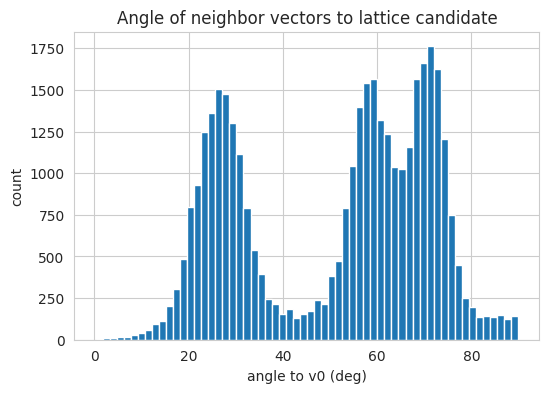

In [25]:
v0 = cluster_centers[0]  # your [0.3227, 0.9128, -0.2501]
v0 /= np.linalg.norm(v0)

dots = pair_vecs @ v0
dots = np.clip(dots, -1.0, 1.0)
angles = np.degrees(np.arccos(np.abs(dots)))  # nematic: v ≡ -v

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(angles, bins=60)
plt.xlabel("angle to v0 (deg)")
plt.ylabel("count")
plt.title("Angle of neighbor vectors to lattice candidate")
plt.show()



GLOBAL COM PLANE & LONG-AXIS ALIGNMENT

Global best-fit plane normal (unit vector): [ 0.04470076 -0.29284212  0.9551154 ]
Plane center (mean COM): [ 8.257468  7.508999 12.081985]

Angle between long axis and plane normal (degrees):
  mean = 14.93°
  std  = 8.23°
  min  = 0.17°
  max  = 89.55°

Fraction with |angle| < 20.0° (≈ parallel): 89.7%


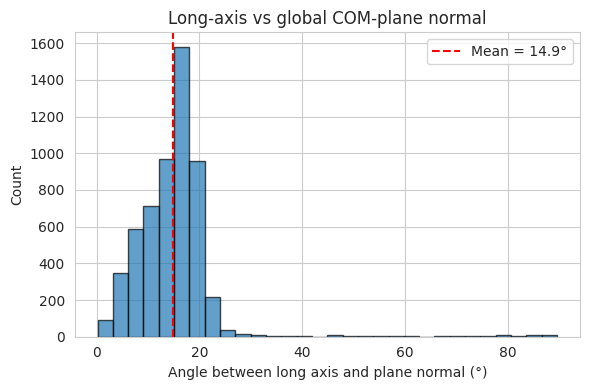

In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("GLOBAL COM PLANE & LONG-AXIS ALIGNMENT")
print("="*80)

# ------------------------------------------------------------
# 1. Collect COM coordinates
# ------------------------------------------------------------
coords = df[['com_x', 'com_y', 'com_z']].values  # shape (N, 3)

# Center the coordinates
com_mean = coords.mean(axis=0)
coords_centered = coords - com_mean

# ------------------------------------------------------------
# 2. Fit best-fit plane via SVD (NumPy only)
#    The normal is the singular vector corresponding to
#    the smallest singular value.
# ------------------------------------------------------------
u, s, vt = np.linalg.svd(coords_centered, full_matrices=False)
plane_normal = vt[-1]        # last row of V^T => normal direction
plane_normal = plane_normal / np.linalg.norm(plane_normal)

print(f"\nGlobal best-fit plane normal (unit vector): {plane_normal}")
print(f"Plane center (mean COM): {com_mean}")

# ------------------------------------------------------------
# 3. Angle between long axis and plane normal (per residue)
#    Use abs(dot) because long-axis is nematic (±n equivalent)
# ------------------------------------------------------------
long_axes = df[['long_x', 'long_y', 'long_z']].values  # (N, 3)

dots = np.einsum('ij,j->i', long_axes, plane_normal)   # dot(long_i, n_plane)
dots_abs = np.abs(dots)                                # nematic symmetry
dots_abs = np.clip(dots_abs, -1.0, 1.0)                # numerical safety

angles = np.degrees(np.arccos(dots_abs))               # in degrees

df['long_angle_plane_normal'] = angles

print("\nAngle between long axis and plane normal (degrees):")
print(f"  mean = {angles.mean():.2f}°")
print(f"  std  = {angles.std():.2f}°")
print(f"  min  = {angles.min():.2f}°")
print(f"  max  = {angles.max():.2f}°")

# ------------------------------------------------------------
# 4. Simple classification: "parallel" vs "not parallel"
#    You can adjust thresholds as you like.
# ------------------------------------------------------------
PARALLEL_THRESH = 20.0   # degrees

df['long_parallel_to_plane_normal'] = df['long_angle_plane_normal'] < PARALLEL_THRESH

frac_parallel = df['long_parallel_to_plane_normal'].mean() * 100.0
print(f"\nFraction with |angle| < {PARALLEL_THRESH:.1f}° (≈ parallel): {frac_parallel:.1f}%")

# ------------------------------------------------------------
# 5. Plot distribution
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(angles, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(angles.mean(), color='red', linestyle='--',
            label=f"Mean = {angles.mean():.1f}°")
plt.xlabel("Angle between long axis and plane normal (°)")
plt.ylabel("Count")
plt.title("Long-axis vs global COM-plane normal")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Use the same number of bins as in your histogram
NBINS = 30

# Compute bin edges exactly like matplotlib does
bin_edges = np.histogram_bin_edges(angles, bins=NBINS)

# Assign each residue to a bin index: 0 .. NBINS-1
bin_idx = np.digitize(df['long_angle_plane_normal'].values, bin_edges) - 1
bin_idx = np.clip(bin_idx, 0, NBINS - 1)

df['angle_bin'] = bin_idx
# optional: store bin center for information
df['angle_bin_center'] = 0.5 * (bin_edges[bin_idx] + bin_edges[bin_idx + 1])

# Check that counts per bin match the histogram
counts, _ = np.histogram(angles, bins=bin_edges)
print("Counts per bin (same as bars):")
print(counts)


Counts per bin (same as bars):
[ 12  86 425 969 719 303 138  80  30  24  17  10   2   1   0   0   3   5
   6   1   2   3   1   1   0   2   3   3   6   4]


In [29]:
# import py3Dmol

# # Path to the gro file you used to build `sites` / `df`
# # GRO_FILE = "path/to/your/file.gro"   # <--- put your actual path here

# # Build a color for each bin using a colormap
# cmap = cm.get_cmap('viridis', NBINS)
# bin_colors = {i: mcolors.to_hex(cmap(i)) for i in range(NBINS)}

# # Print a small legend: bin index -> angle range
# print("\nBin legend (index: [low, high) in degrees):")
# for i in range(NBINS):
#     low = bin_edges[i]
#     high = bin_edges[i+1]
#     print(f"  bin {i:2d}: [{low:5.1f}, {high:5.1f}) -> {bin_colors[i]}")

# # Load the GRO structure as text
# with open(gro_file, "r") as f:
#     gro_text = f.read()

# # Create the py3Dmol viewer
# view = py3Dmol.view(width=900, height=700)
# view.setBackgroundColor('white')
# view.addModel(gro_text, 'gro')

# # First: everything light grey (background)
# view.setStyle({'stick': {'color': 'lightgrey', 'radius': 0.12}})

# # Now recolor each residue according to its angle bin
# for _, row in df.iterrows():
#     resid = int(row['resid'])
#     b = int(row['angle_bin'])
#     color = bin_colors[b]

#     view.setStyle(
#         {'resi': resid},
#         {'stick': {'color': color, 'radius': 0.22}}
#     )

# view.zoomTo()
# # view.show()



Grain populations (by orientation clustering):
grain_label
grain2    3185
grain1    2423
Name: count, dtype: int64


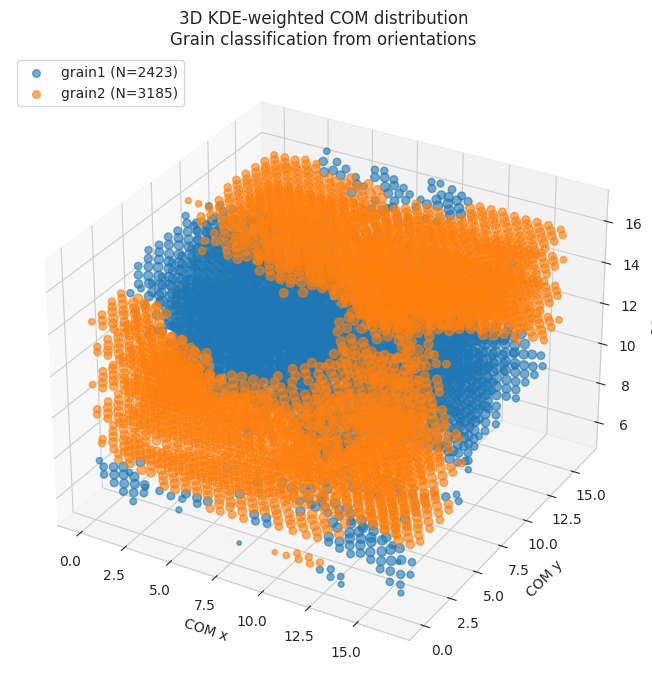

In [7]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# ============================================================
# 1) Build nematic orientation embedding from long-axis vectors
#    (so +n and -n are treated as the same orientation)
# ============================================================
long_vecs = df[["long_x", "long_y", "long_z"]].values

# normalize
norms = np.linalg.norm(long_vecs, axis=1, keepdims=True)
long_unit = long_vecs / np.clip(norms, 1e-8, None)

def nematic_embed(v: np.ndarray) -> np.ndarray:
    """Map unit vectors (N,3) to nematic-invariant embedding (N,6)."""
    x, y, z = v[:, 0], v[:, 1], v[:, 2]
    return np.stack(
        [
            x * x,
            y * y,
            z * z,
            np.sqrt(2.0) * x * y,
            np.sqrt(2.0) * x * z,
            np.sqrt(2.0) * y * z,
        ],
        axis=1,
    )

orient_emb = nematic_embed(long_unit)   # shape (N, 6)

# ============================================================
# 2) Cluster orientations into two grains with Gaussian Mixture
# ============================================================
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=0,
)
grain_label_raw = gmm.fit_predict(orient_emb)   # 0 or 1

df["grain_label_raw"] = grain_label_raw

# (Optional) make labels a bit more interpretable:
# assign "grain1" to the grain with smaller mean COM_y, "grain2" to the other
group_means = df.groupby("grain_label_raw")["com_y"].mean()
order = group_means.sort_values().index.tolist()   # [label_for_grain1, label_for_grain2]

label_map = {
    order[0]: "grain1",
    order[1]: "grain2",
}
df["grain_label"] = df["grain_label_raw"].map(label_map)

print("\nGrain populations (by orientation clustering):")
print(df["grain_label"].value_counts())

# ============================================================
# 3) 3D KDE in COM space (for density-weighted scatter)
# ============================================================
coords = df[["com_x", "com_y", "com_z"]].values  # shape (N, 3)

# KDE over 3D coordinates
# You can tune 'bandwidth' depending on your system size / density
kde = KernelDensity(
    bandwidth=0.5,   # try 0.5–5.0 depending on nm scale
    kernel="gaussian",
)
kde.fit(coords)
log_dens = kde.score_samples(coords)
dens = np.exp(log_dens)  # unnormalized density

# normalize density for nicer visualization
dens_norm = (dens - dens.min()) / (dens.max() - dens.min() + 1e-12)
sizes = 10 + 40 * dens_norm   # point size between 10 and 50

df["local_density"] = dens
df["local_density_norm"] = dens_norm

# ============================================================
# 4) 3D scatter: COM positions, colored by grain, size by KDE density
# ============================================================
color_map = {
    "grain1": "tab:blue",
    "grain2": "tab:orange",
}

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for grain, sub in df.groupby("grain_label"):
    ax.scatter(
        sub["com_x"],
        sub["com_y"],
        sub["com_z"],
        s=10 + 40 * sub["local_density_norm"].values,
        alpha=0.6,
        color=color_map.get(grain, "k"),
        label=f"{grain} (N={len(sub)})",
        depthshade=True,
    )

ax.set_xlabel("COM x")
ax.set_ylabel("COM y")
ax.set_zlabel("COM z")
ax.set_title("3D KDE-weighted COM distribution\nGrain classification from orientations")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()




In [27]:
# import py3Dmol as p3d

# # ------------------------------------------------------------
# # Py3Dmol 3D view of COMs colored by grain label
# # ------------------------------------------------------------

# # Safety check: make sure grain_label exists
# assert "grain_label" in df.columns, "df['grain_label'] is missing – run the clustering step first."

# color_map = {
#     "grain1": "blue",
#     "grain2": "orange",
# }

# view = p3d.view(width=700, height=600)

# model_index = 0
# for grain, sub in df.groupby("grain_label"):
#     if sub.empty:
#         continue

#     # Build XYZ block: one dummy atom per COM
#     # Element type "C" is arbitrary here – we just need a point.
#     xyz_lines = []
#     xyz_lines.append(str(len(sub)))          # number of atoms
#     xyz_lines.append(grain)                  # comment line
#     for _, row in sub.iterrows():
#         xyz_lines.append(
#             f"C {row['com_x']:.3f} {row['com_y']:.3f} {row['com_z']:.3f}"
#         )
#     xyz_block = "\n".join(xyz_lines) + "\n"

#     # Add as a separate model for each grain so we can style independently
#     view.addModel(xyz_block, "xyz")
#     view.setStyle(
#         {"model": model_index},
#         {
#             "sphere": {
#                 "radius": 0.3,             # tweak for bigger/smaller points
#                 "color": color_map.get(grain, "grey"),
#             }
#         },
#     )
#     model_index += 1

# # General view settings
# view.setBackgroundColor("0xFFFFFF")  # white background
# view.zoomTo()

# # Optional: show a bounding box
# # view.addBox({"center": {"x": float(df["com_x"].mean()),
# #                         "y": float(df["com_y"].mean()),
# #                         "z": float(df["com_z"].mean())},
# #              "dimensions": {"w": float(df["com_x"].max()-df["com_x"].min()),
# #                             "h": float(df["com_y"].max()-df["com_y"].min()),
# #                             "d": float(df["com_z"].max()-df["com_z"].min())},
# #              "color": "lightgrey"})

# view.show()


In [26]:
# from sklearn.mixture import GaussianMixture
# import numpy as np

# # plane_normal from your global COM fit (you already computed it)
# # normals from PCA
# normals = df[["normal_x", "normal_y", "normal_z"]].values

# # normalize
# norms = np.linalg.norm(normals, axis=1, keepdims=True)
# normals_unit = normals / np.clip(norms, 1e-8, None)

# # fix sign so all normals “face” the same side of the global plane
# dots = normals_unit @ plane_normal
# sign = np.sign(dots)
# sign[sign == 0] = 1.0
# normals_oriented = normals_unit * sign[:, None]   # (N, 3)

# gmm = GaussianMixture(
#     n_components=2,
#     covariance_type="full",
#     random_state=0,
# )
# grain_raw = gmm.fit_predict(normals_oriented)   # 0 or 1

# df["grain_label_raw"] = grain_raw

# # Make grain1 = one with lower mean COM_y (or x, depending on GB direction)
# group_means = df.groupby("grain_label_raw")["com_y"].mean()
# order = group_means.sort_values().index.tolist()  # [label_of_left, label_of_right]

# label_map = {order[0]: "grain1", order[1]: "grain2"}
# df["grain_label"] = df["grain_label_raw"].map(label_map)

# print(df["grain_label"].value_counts())

# import py3Dmol as p3d

# color_map = {"grain1": "blue", "grain2": "orange"}

# view = p3d.view(width=700, height=600)

# model_index = 0
# for grain, sub in df.groupby("grain_label"):
#     if sub.empty:
#         continue

#     xyz_lines = [str(len(sub)), grain]
#     for _, row in sub.iterrows():
#         xyz_lines.append(f"C {row['com_x']:.3f} {row['com_y']:.3f} {row['com_z']:.3f}")
#     xyz_block = "\n".join(xyz_lines) + "\n"

#     view.addModel(xyz_block, "xyz")
#     view.setStyle(
#         {"model": model_index},
#         {"sphere": {"radius": 0.3, "color": color_map.get(grain, "grey")}},
#     )
#     model_index += 1

# view.setBackgroundColor("0xFFFFFF")
# view.zoomTo()
# view.show()



In [35]:
# ------------------------------------------------------------
# Compute angle between molecular normal and plane normal
# ------------------------------------------------------------
normals = df[['normal_x','normal_y','normal_z']].values

# normalize normals
norms = np.linalg.norm(normals, axis=1, keepdims=True)
normals_unit = normals / np.clip(norms, 1e-8, None)

# angle in degrees
dots = np.einsum('ij,j->i', normals_unit, plane_normal)
dots = np.clip(dots, -1.0, 1.0)
angles_normal_plane = np.degrees(np.arccos(dots))

df['normal_angle_plane_normal'] = angles_normal_plane

print("\nAngle stats:")
print(df['normal_angle_plane_normal'].describe())



Angle stats:
count    2856.000000
mean       76.462898
std        10.240775
min        25.436134
25%        70.808743
50%        75.551826
75%        80.547768
max       155.033737
Name: normal_angle_plane_normal, dtype: float64


In [38]:
# ------------------------------------------------------------
# Cluster grains based on oriented molecular normals
# ------------------------------------------------------------
from sklearn.mixture import GaussianMixture
import numpy as np

normals = df[['normal_x','normal_y','normal_z']].values

# Normalize
norms = np.linalg.norm(normals, axis=1, keepdims=True)
normals_unit = normals / np.clip(norms, 1e-8, None)

# Orient normals to same half-space using plane_normal
dots = normals_unit @ plane_normal
sign = np.sign(dots)
sign[sign == 0] = 1.0
normals_oriented = normals_unit * sign[:, None]

# GMM clustering
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
grain_raw = gmm.fit_predict(normals_oriented)
df['grain_label_raw'] = grain_raw

# Sort grains by mean COM_y to assign stable grain1 / grain2 names
group_means = df.groupby("grain_label_raw")["com_y"].mean()
order = group_means.sort_values().index.tolist()  # [left-grain, right-grain]

label_map = {order[0]: "grain1", order[1]: "grain2"}
df['grain_label'] = df['grain_label_raw'].map(label_map)

print(df['grain_label'].value_counts())


grain_label
grain1    1666
grain2    1190
Name: count, dtype: int64


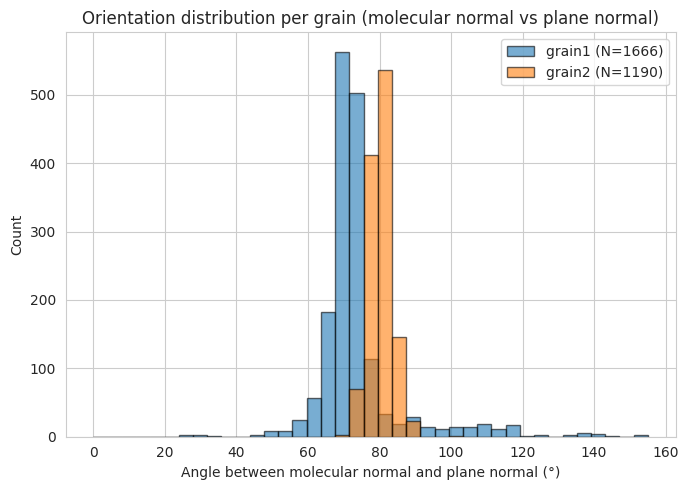

In [39]:
# ------------------------------------------------------------
# Histogram: normal-angle to plane-normal for each grain
# ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

bins = np.linspace(0, df['normal_angle_plane_normal'].max(), 40)

for grain, sub in df.groupby("grain_label"):
    ax.hist(
        sub["normal_angle_plane_normal"],
        bins=bins,
        alpha=0.6,
        label=f"{grain} (N={len(sub)})",
        edgecolor='black'
    )

ax.set_xlabel("Angle between molecular normal and plane normal (°)")
ax.set_ylabel("Count")
ax.set_title("Orientation distribution per grain (molecular normal vs plane normal)")
ax.legend()
plt.tight_layout()
plt.show()


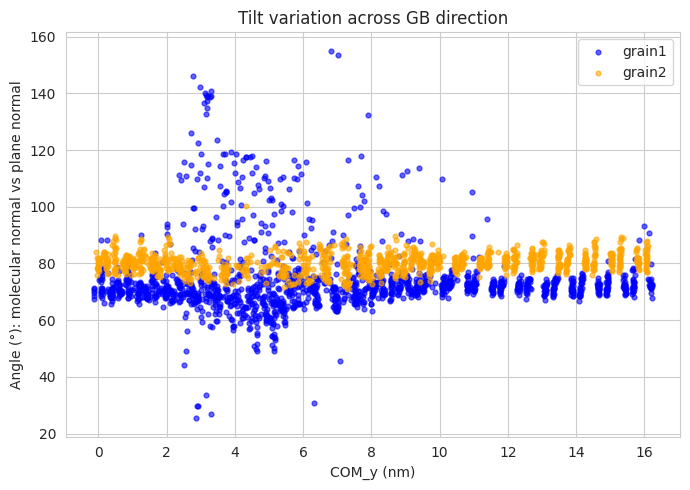

In [40]:
# ------------------------------------------------------------
# Scatter: COM_y vs normal-angle, colored by grain label
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

color_map = {"grain1": "blue", "grain2": "orange"}

for grain, sub in df.groupby("grain_label"):
    ax.scatter(
        sub["com_y"],
        sub["normal_angle_plane_normal"],
        s=12,
        alpha=0.6,
        color=color_map.get(grain, 'grey'),
        label=f"{grain}"
    )

ax.set_xlabel("COM_y (nm)")
ax.set_ylabel("Angle (°): molecular normal vs plane normal")
ax.set_title("Tilt variation across GB direction")
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
import MDAnalysis as mda
from MDAnalysis.coordinates.GRO import GROWriter

# path to the original slab .gro
INPUT_GRO = "/home/sgarg/structural_analysis_gb/a45_test/slab_11/slab_11.gro"   # <-- change this

u = mda.Universe(INPUT_GRO)

def write_gro_for_resids(universe, resid_list, out_gro):
    """Write a .gro containing only the given residue IDs."""
    if len(resid_list) == 0:
        print(f"[skip] No residues for {out_gro}")
        return
    resid_str = " ".join(str(r) for r in resid_list)
    ag = universe.select_atoms(f"resid {resid_str}")
    print(f"[write] {out_gro}: {len(ag)} atoms, {len(resid_list)} residues")
    with GROWriter(out_gro, n_atoms=len(ag)) as W:
        W.write(ag)

# write one .gro per grain
write_gro_for_resids(u, grain1_resids, "grain1.gro")
write_gro_for_resids(u, grain2_resids, "grain2.gro")


[write] grain1.gro: 59976 atoms, 1666 residues
[write] grain2.gro: 42840 atoms, 1190 residues


In [25]:
# import numpy as np
# import py3Dmol as p3d

# assert "normal_angle_plane_normal" in df.columns, "Compute angle column first."

# # Define angle bins and colors
# angle = df["normal_angle_plane_normal"].values
# low_thr, high_thr = 10.0, 25.0   # example thresholds; tweak as needed

# def angle_category(a):
#     if a < low_thr:
#         return "low"
#     elif a < high_thr:
#         return "mid"
#     else:
#         return "high"

# df["angle_cat"] = [angle_category(a) for a in angle]

# color_map_angle = {
#     "low":  "green",
#     "mid":  "yellow",
#     "high": "red",
# }

# view_angle = p3d.view(width=700, height=600)


# model_index = 0
# for cat, sub in df.groupby("angle_cat"):
#     if sub.empty:
#         continue

#     lines = [str(len(sub)), f"angle_{cat}"]
#     for _, row in sub.iterrows():
#         lines.append(f"C {row['com_x']:.3f} {row['com_y']:.3f} {row['com_z']:.3f}")
#     xyz_block = "\n".join(lines) + "\n"

#     view_angle.addModel(xyz_block, "xyz")
#     view_angle.setStyle(
#         {"model": model_index},
#         {"sphere": {"radius": 0.35, "color": color_map_angle.get(cat, "grey")}},
#     )
#     model_index += 1

# view_angle.setBackgroundColor("white")
# view_angle.zoomTo()
# view_angle.show()



SPATIAL MAP OF MISORIENTATION (LONG AXIS vs PLANE NORMAL)


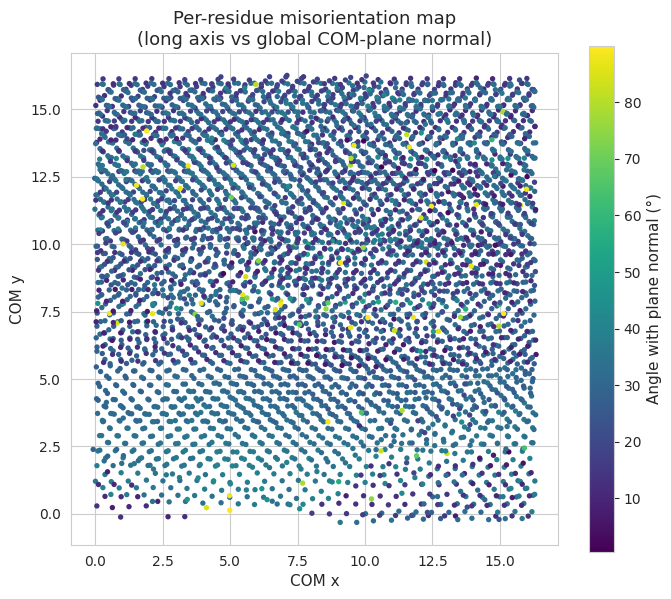

In [37]:
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("SPATIAL MAP OF MISORIENTATION (LONG AXIS vs PLANE NORMAL)")
print("="*80)

x = df['com_x'].values
y = df['com_y'].values
angles = df['long_angle_plane_normal'].values   # already in degrees

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    x, y,
    c=angles,
    s=15,
    cmap='viridis',      # you can try 'plasma', 'turbo', etc.
    edgecolors='none'
)

cbar = plt.colorbar(sc)
cbar.set_label("Angle with plane normal (°)", fontsize=11)

plt.xlabel("COM x", fontsize=11)
plt.ylabel("COM y", fontsize=11)
plt.title("Per-residue misorientation map\n(long axis vs global COM-plane normal)", fontsize=13)
plt.gca().set_aspect('equal', 'box')   # so x,y scale are comparable
plt.tight_layout()
plt.show()


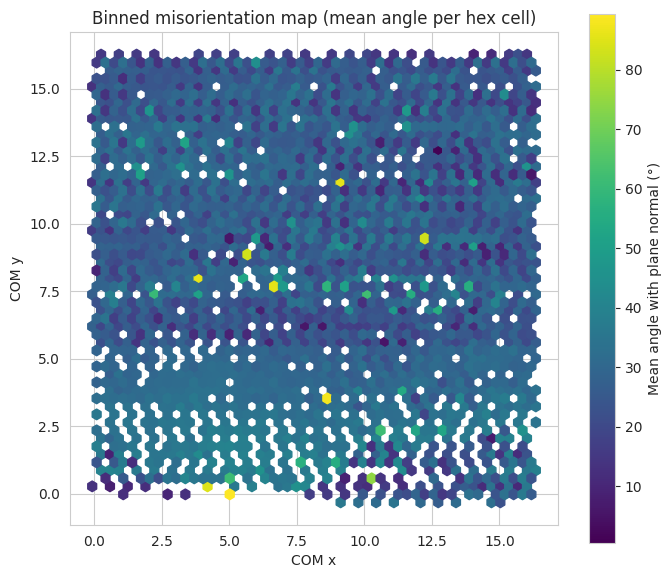

In [39]:
plt.figure(figsize=(7, 6))
hb = plt.hexbin(
    x, y,
    C=angles,
    gridsize=50,
    reduce_C_function=np.mean,
    cmap='viridis', #vmin=10, vmax=20
)
cbar = plt.colorbar(hb)
cbar.set_label("Mean angle with plane normal (°)")
plt.xlabel("COM x")
plt.ylabel("COM y")
plt.title("Binned misorientation map (mean angle per hex cell)")
plt.gca().set_aspect('equal', 'box')

plt.tight_layout()
plt.show()



3D SCATTER HEAT MAP OF MISORIENTATION


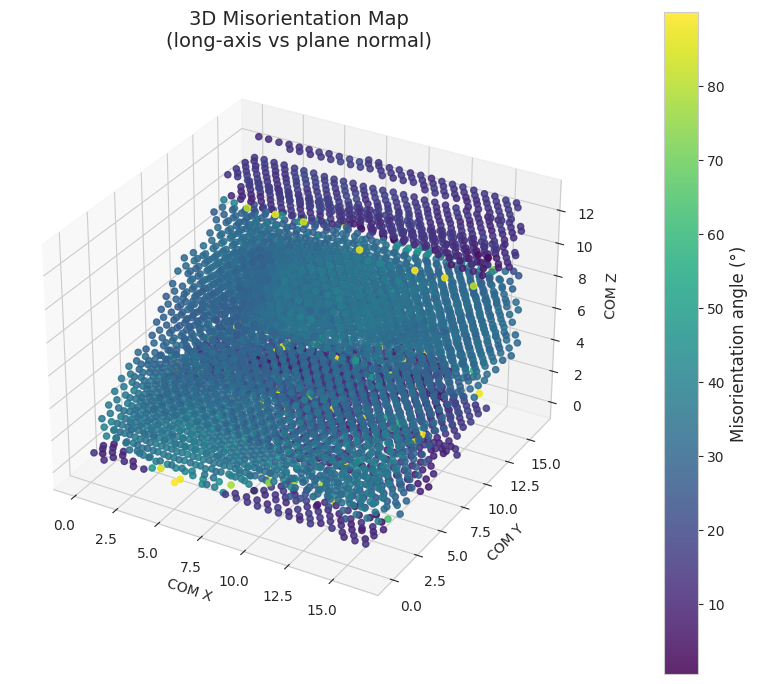

In [40]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("3D SCATTER HEAT MAP OF MISORIENTATION")
print("="*80)

# Extract coordinates & angles
x = df['com_x'].values
y = df['com_y'].values
z = df['com_z'].values
angles = df['long_angle_plane_normal'].values

# Create 3D scatter plot
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x, y, z,
    c=angles,
    cmap='viridis',
    s=20,
    alpha=0.85, #vmin=10, vmax=20
)

cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Misorientation angle (°)", fontsize=12)

ax.set_xlabel("COM X")
ax.set_ylabel("COM Y")
ax.set_zlabel("COM Z")
ax.set_title("3D Misorientation Map\n(long-axis vs plane normal)", fontsize=14)

plt.tight_layout()
plt.show()


In [22]:
# Select the columns you want in the output CSV
output_df = df[['resid',
                'com_x', 'com_y', 'com_z',
                'long_angle_plane_normal']]

# Name of output file
csv_name = "misorientation_with_plane_normal.csv"

# Save to CSV
output_df.to_csv(csv_name, index=False)

print(f"CSV saved: {csv_name}")
print(output_df.head())


CSV saved: misorientation_with_plane_normal.csv
   resid      com_x      com_y      com_z  long_angle_plane_normal
0    173  14.887548  13.466337  14.129438                20.625326
1    209   1.366827  14.667892  14.035145                18.389261
2    281   0.077468  13.861522  14.084703                21.333359
3    285  13.082399  14.259098  14.161657                18.437675
4    293  13.432161  14.663682  14.166750                19.304073


In [51]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import connected_components

# ---------------------------------------------
# Parameters
# ---------------------------------------------
R_NEIGH = 0.6      # nm  (≈ 6 Å)
ANGLE_TOL = 2.0    # degrees
MIN_GRAIN_SIZE = 30

coords = df[['com_x', 'com_y', 'com_z']].values
angles = df['long_angle_plane_normal'].values
n = len(df)

print(f"[info] Using R_NEIGH={R_NEIGH} nm, ANGLE_TOL={ANGLE_TOL}° for clustering")

# ---------------------------------------------
# 1) Build spatial neighborhood (within radius)
# ---------------------------------------------
nbrs = NearestNeighbors(radius=R_NEIGH)
nbrs.fit(coords)
distances, indices = nbrs.radius_neighbors(coords, radius=R_NEIGH)

# ---------------------------------------------
# 2) Build adjacency graph: connect i-j if
#    (within radius) AND (angle diff <= ANGLE_TOL)
# ---------------------------------------------
adj = lil_matrix((n, n), dtype=bool)

for i, neigh_idx in enumerate(indices):
    ai = angles[i]
    for j in neigh_idx:
        if i == j:
            continue
        if abs(ai - angles[j]) <= ANGLE_TOL:
            adj[i, j] = True
            adj[j, i] = True

# ---------------------------------------------
# 3) Connected components = preliminary grains
# ---------------------------------------------
n_components, labels = connected_components(adj, directed=False)
df['grain_id_raw'] = labels

print(f"[info] Found {n_components} connected components (raw grains)")

# ---------------------------------------------
# 4) Filter out tiny clusters as noise
# ---------------------------------------------
sizes = df['grain_id_raw'].value_counts().sort_index()
valid_grains = [gid for gid, sz in sizes.items() if sz >= MIN_GRAIN_SIZE]

print("[info] Grain sizes (raw):")
for gid, sz in sizes.items():
    print(f"  id {gid}: N={sz}")

print(f"[info] Keeping grains with N >= {MIN_GRAIN_SIZE}: {valid_grains}")

# Map raw ids → compact grain index (0,1,2,...) or -1 for noise
id_map = {gid: idx for idx, gid in enumerate(valid_grains)}
df['grain_id'] = df['grain_id_raw'].apply(lambda g: id_map.get(g, -1))

# ---------------------------------------------
# 5) Mean angle per grain (only valid grains)
# ---------------------------------------------
print("\n[stats] Mean misorientation per grain:")
for gid in sorted(id_map.values()):
    mask = df['grain_id'] == gid
    mean_angle = df.loc[mask, 'long_angle_plane_normal'].mean()
    std_angle = df.loc[mask, 'long_angle_plane_normal'].std()
    count = mask.sum()
    print(f"  grain {gid}: mean={mean_angle:.2f}°, std={std_angle:.2f}°, N={count}")

# ---------------------------------------------
# 6) Identify GB molecules:
#    molecules whose neighborhood contains
#    neighbors from >= 2 different valid grains
# ---------------------------------------------
grain_ids = df['grain_id'].values
is_gb = np.zeros(n, dtype=bool)

for i, neigh_idx in enumerate(indices):
    # grain ids of neighbors (only valid grains: gid >= 0)
    neigh_gids = {grain_ids[j] for j in neigh_idx if grain_ids[j] >= 0 and j != i}
    if len(neigh_gids) >= 2:
        is_gb[i] = True

df['is_GB'] = is_gb

# Convenient label column: 'grain0', 'grain1', ..., or 'GB'
def label_row(row):
    if row['is_GB'] or row['grain_id'] < 0:
        return 'GB'
    else:
        return f"grain{int(row['grain_id'])}"

df['grain_label'] = df.apply(label_row, axis=1)

print(f"\n[summary] GB molecules: {df['is_GB'].sum()} / {n}")


[info] Using R_NEIGH=0.6 nm, ANGLE_TOL=2.0° for clustering
[info] Found 626 connected components (raw grains)
[info] Grain sizes (raw):
  id 0: N=1
  id 1: N=379
  id 2: N=77
  id 3: N=137
  id 4: N=8
  id 5: N=2
  id 6: N=1
  id 7: N=36
  id 8: N=21
  id 9: N=6
  id 10: N=306
  id 11: N=27
  id 12: N=1
  id 13: N=391
  id 14: N=1
  id 15: N=1
  id 16: N=1
  id 17: N=1
  id 18: N=2
  id 19: N=91
  id 20: N=8
  id 21: N=1
  id 22: N=1
  id 23: N=75
  id 24: N=855
  id 25: N=5
  id 26: N=6
  id 27: N=2
  id 28: N=6
  id 29: N=5
  id 30: N=2
  id 31: N=1
  id 32: N=1
  id 33: N=1
  id 34: N=1
  id 35: N=1
  id 36: N=2
  id 37: N=1
  id 38: N=1
  id 39: N=1
  id 40: N=1
  id 41: N=1
  id 42: N=1
  id 43: N=340
  id 44: N=2
  id 45: N=1
  id 46: N=1
  id 47: N=1
  id 48: N=1
  id 49: N=27
  id 50: N=5
  id 51: N=1
  id 52: N=4
  id 53: N=1
  id 54: N=1
  id 55: N=1
  id 56: N=1
  id 57: N=1
  id 58: N=17
  id 59: N=1
  id 60: N=30
  id 61: N=1
  id 62: N=356
  id 63: N=1
  id 64: N=1
  id 6


ANGULAR DISTRIBUTION ANALYSIS

Long axis alignment with global axes (degrees):
  X-axis: mean=76.86°, std=5.69°
  Y-axis: mean=72.63°, std=5.03°
  Z-axis: mean=22.63°, std=6.71°

Normal axis alignment with global axes (degrees):
  X-axis: mean=66.51°, std=12.06°
  Y-axis: mean=30.52°, std=11.22°
  Z-axis: mean=74.28°, std=7.32°


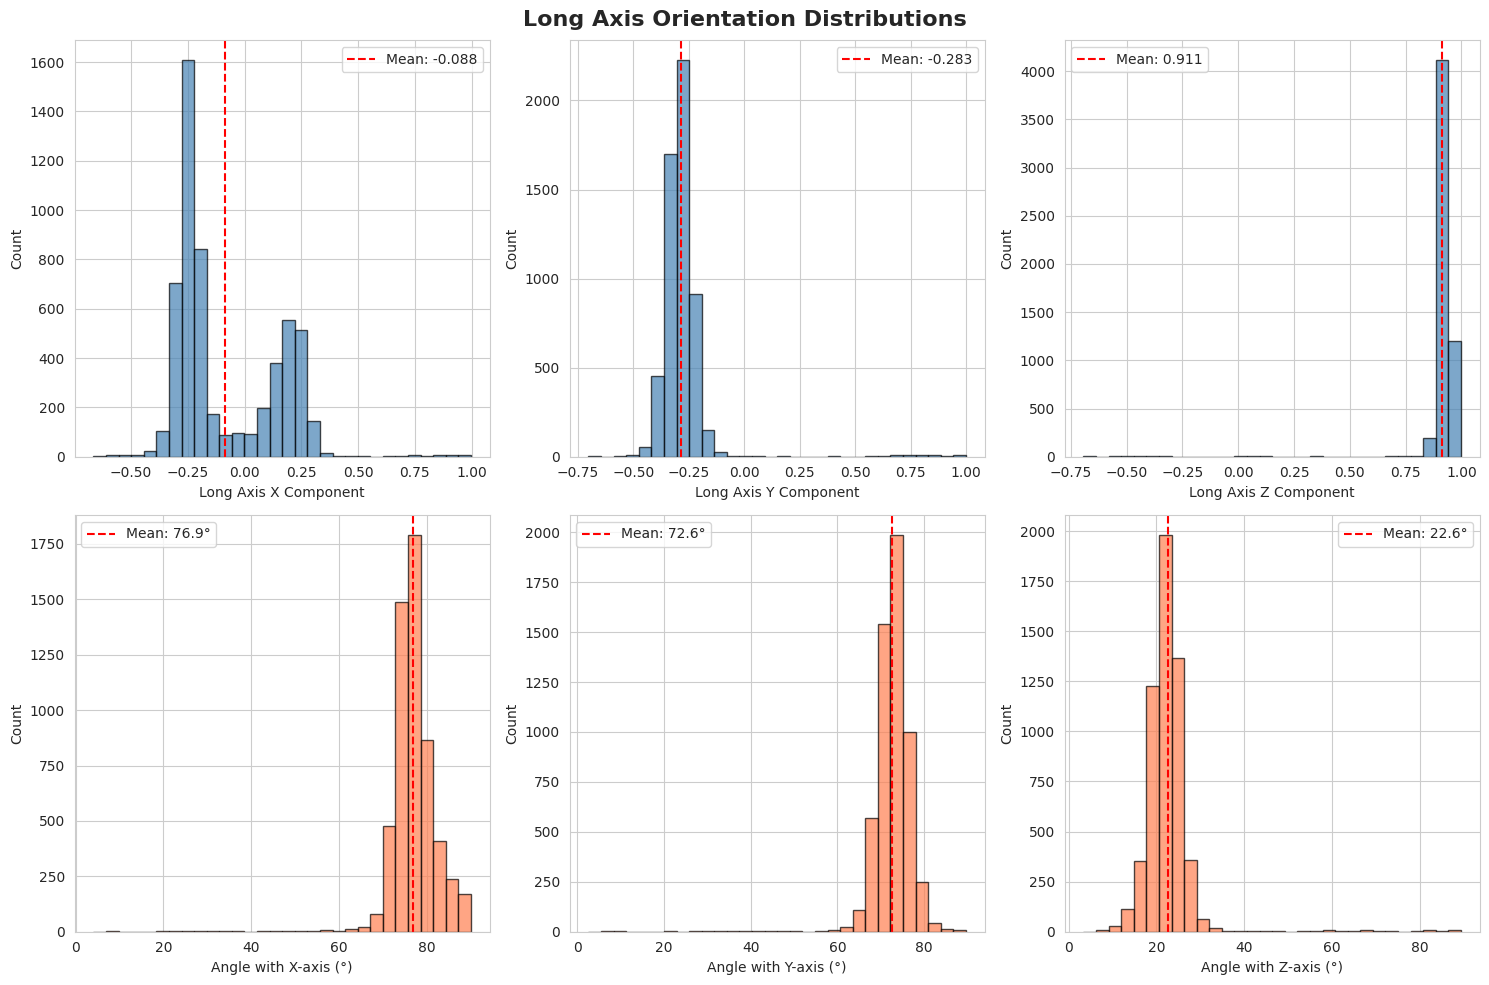

In [8]:
"""
## Step 4: Distribution Analysis and Classification
"""

# %%
print("\n" + "="*80)
print("ANGULAR DISTRIBUTION ANALYSIS")
print("="*80)

# Calculate angles with global coordinate axes (X, Y, Z)
# For long axis
df['long_angle_x'] = np.degrees(np.arccos(np.abs(df['long_x'])))
df['long_angle_y'] = np.degrees(np.arccos(np.abs(df['long_y'])))
df['long_angle_z'] = np.degrees(np.arccos(np.abs(df['long_z'])))

# For normal axis
df['normal_angle_x'] = np.degrees(np.arccos(np.abs(df['normal_x'])))
df['normal_angle_y'] = np.degrees(np.arccos(np.abs(df['normal_y'])))
df['normal_angle_z'] = np.degrees(np.arccos(np.abs(df['normal_z'])))

print("\nLong axis alignment with global axes (degrees):")
print(f"  X-axis: mean={df['long_angle_x'].mean():.2f}°, std={df['long_angle_x'].std():.2f}°")
print(f"  Y-axis: mean={df['long_angle_y'].mean():.2f}°, std={df['long_angle_y'].std():.2f}°")
print(f"  Z-axis: mean={df['long_angle_z'].mean():.2f}°, std={df['long_angle_z'].std():.2f}°")

print("\nNormal axis alignment with global axes (degrees):")
print(f"  X-axis: mean={df['normal_angle_x'].mean():.2f}°, std={df['normal_angle_x'].std():.2f}°")
print(f"  Y-axis: mean={df['normal_angle_y'].mean():.2f}°, std={df['normal_angle_y'].std():.2f}°")
print(f"  Z-axis: mean={df['normal_angle_z'].mean():.2f}°, std={df['normal_angle_z'].std():.2f}°")

# %%
# Visualization 1: Long Axis Orientation Distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Long Axis Orientation Distributions', fontsize=16, fontweight='bold')

# Long axis components
axes[0, 0].hist(df['long_x'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Long Axis X Component')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['long_x'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_x"].mean():.3f}')
axes[0, 0].legend()

axes[0, 1].hist(df['long_y'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('Long Axis Y Component')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df['long_y'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_y"].mean():.3f}')
axes[0, 1].legend()

axes[0, 2].hist(df['long_z'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 2].set_xlabel('Long Axis Z Component')
axes[0, 2].set_ylabel('Count')
axes[0, 2].axvline(df['long_z'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_z"].mean():.3f}')
axes[0, 2].legend()

# Long axis angles
axes[1, 0].hist(df['long_angle_x'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Angle with X-axis (°)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(df['long_angle_x'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_angle_x"].mean():.1f}°')
axes[1, 0].legend()

axes[1, 1].hist(df['long_angle_y'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Angle with Y-axis (°)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(df['long_angle_y'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_angle_y"].mean():.1f}°')
axes[1, 1].legend()

axes[1, 2].hist(df['long_angle_z'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 2].set_xlabel('Angle with Z-axis (°)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].axvline(df['long_angle_z'].mean(), color='red', linestyle='--', label=f'Mean: {df["long_angle_z"].mean():.1f}°')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


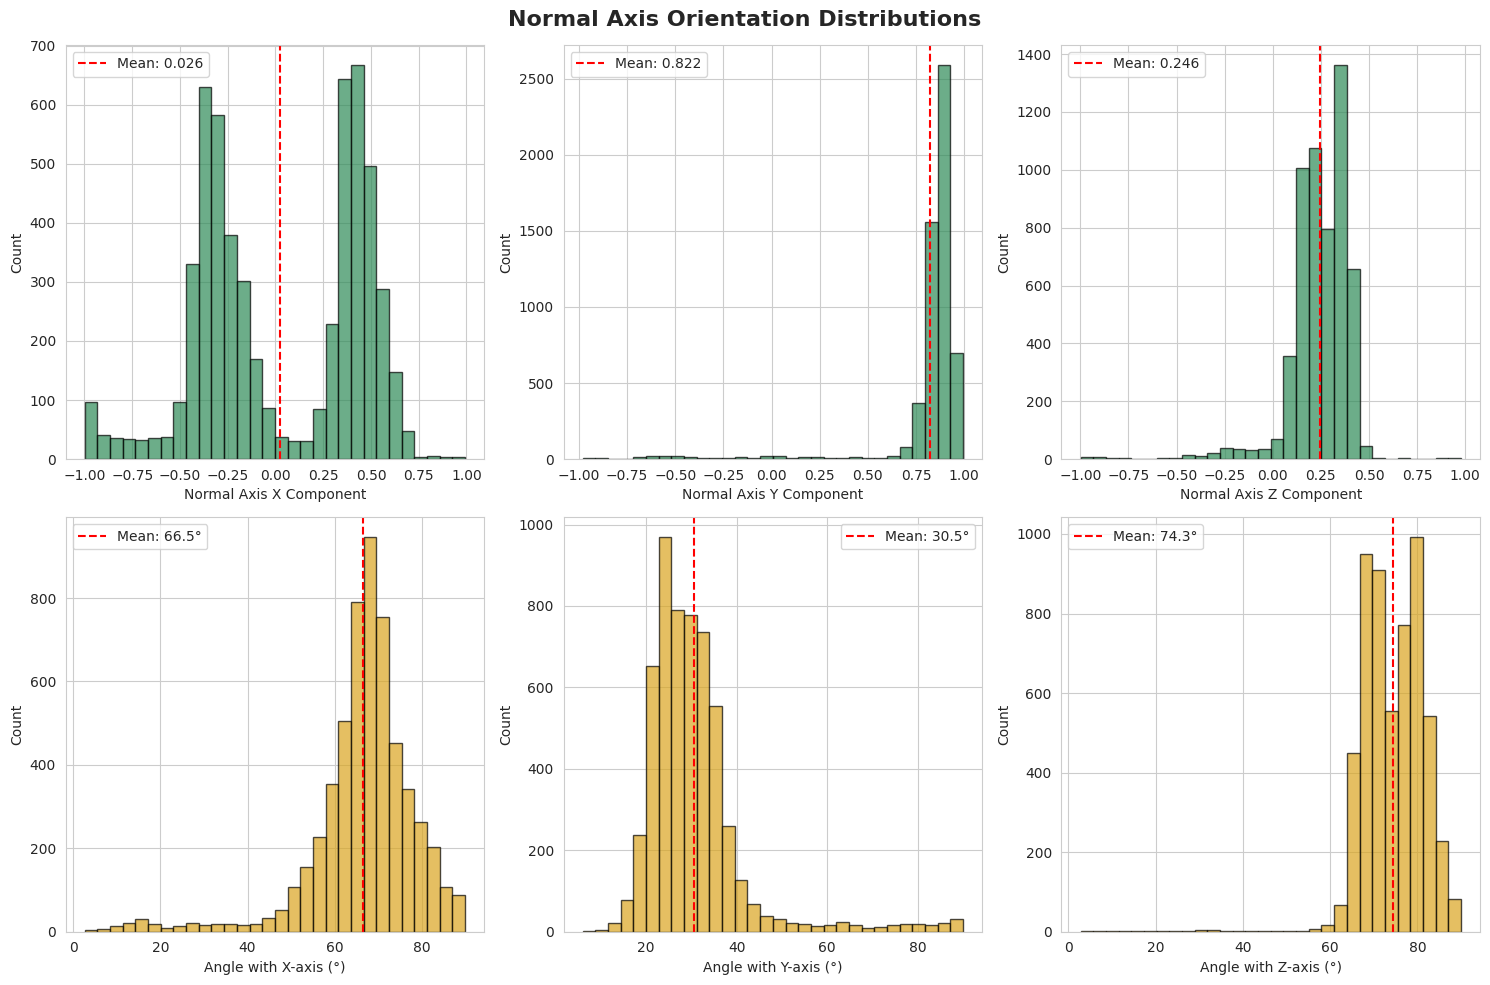

In [9]:
# %%
# Visualization 2: Normal Axis Orientation Distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Normal Axis Orientation Distributions', fontsize=16, fontweight='bold')

# Normal axis components
axes[0, 0].hist(df['normal_x'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 0].set_xlabel('Normal Axis X Component')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['normal_x'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_x"].mean():.3f}')
axes[0, 0].legend()

axes[0, 1].hist(df['normal_y'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].set_xlabel('Normal Axis Y Component')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df['normal_y'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_y"].mean():.3f}')
axes[0, 1].legend()

axes[0, 2].hist(df['normal_z'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 2].set_xlabel('Normal Axis Z Component')
axes[0, 2].set_ylabel('Count')
axes[0, 2].axvline(df['normal_z'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_z"].mean():.3f}')
axes[0, 2].legend()

# Normal axis angles
axes[1, 0].hist(df['normal_angle_x'], bins=30, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1, 0].set_xlabel('Angle with X-axis (°)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(df['normal_angle_x'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_angle_x"].mean():.1f}°')
axes[1, 0].legend()

axes[1, 1].hist(df['normal_angle_y'], bins=30, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1, 1].set_xlabel('Angle with Y-axis (°)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(df['normal_angle_y'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_angle_y"].mean():.1f}°')
axes[1, 1].legend()

axes[1, 2].hist(df['normal_angle_z'], bins=30, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1, 2].set_xlabel('Angle with Z-axis (°)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].axvline(df['normal_angle_z'].mean(), color='red', linestyle='--', label=f'Mean: {df["normal_angle_z"].mean():.1f}°')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

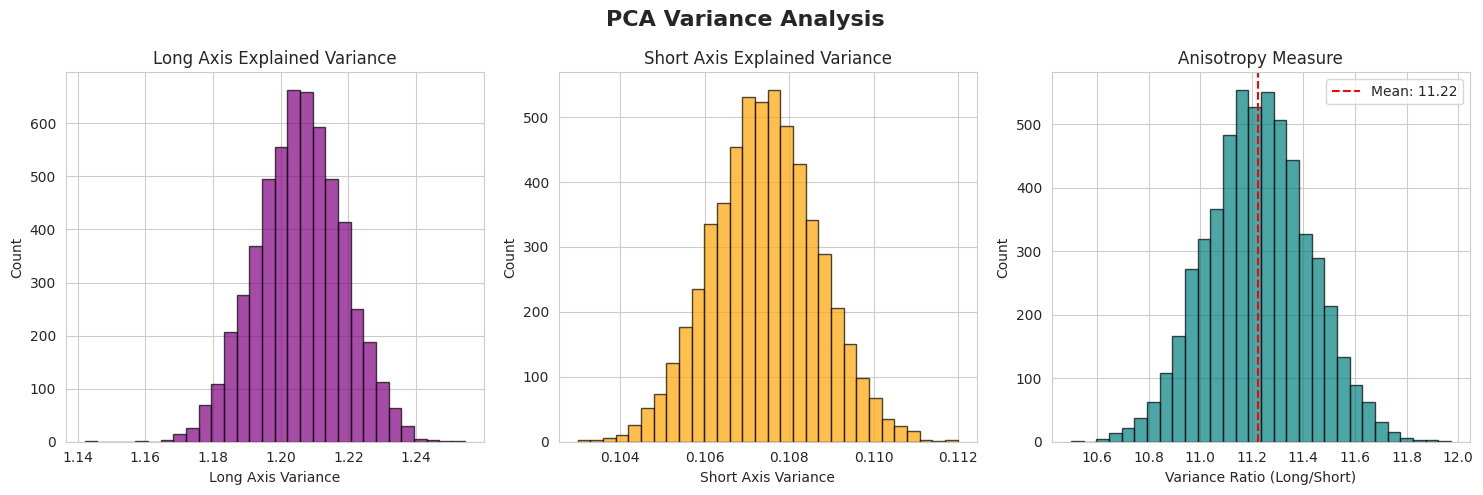

In [10]:
# Visualization 3: Variance Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PCA Variance Analysis', fontsize=16, fontweight='bold')

axes[0].hist(df['var_long'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_xlabel('Long Axis Variance')
axes[0].set_ylabel('Count')
axes[0].set_title('Long Axis Explained Variance')

axes[1].hist(df['var_short'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Short Axis Variance')
axes[1].set_ylabel('Count')
axes[1].set_title('Short Axis Explained Variance')

axes[2].hist(df['var_ratio'], bins=30, edgecolor='black', alpha=0.7, color='teal')
axes[2].set_xlabel('Variance Ratio (Long/Short)')
axes[2].set_ylabel('Count')
axes[2].set_title('Anisotropy Measure')
axes[2].axvline(df['var_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df["var_ratio"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()


Long Axis Classification:
long_axis_class
aligned_with_Z    5464
mixed              114
aligned_with_Y      16
aligned_with_X      14
Name: count, dtype: int64

Percentages:
long_axis_class
aligned_with_Z    97.432240
mixed              2.032810
aligned_with_Y     0.285307
aligned_with_X     0.249643
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Normal Axis Classification:
normal_axis_class
normal_to_Y    3207
mixed          2238
normal_to_X     143
normal_to_Z      20
Name: count, dtype: int64

Percentages:
normal_axis_class
normal_to_Y    57.186163
mixed          39.907275
normal_to_X     2.549929
normal_to_Z     0.356633
Name: proportion, dtype: float64


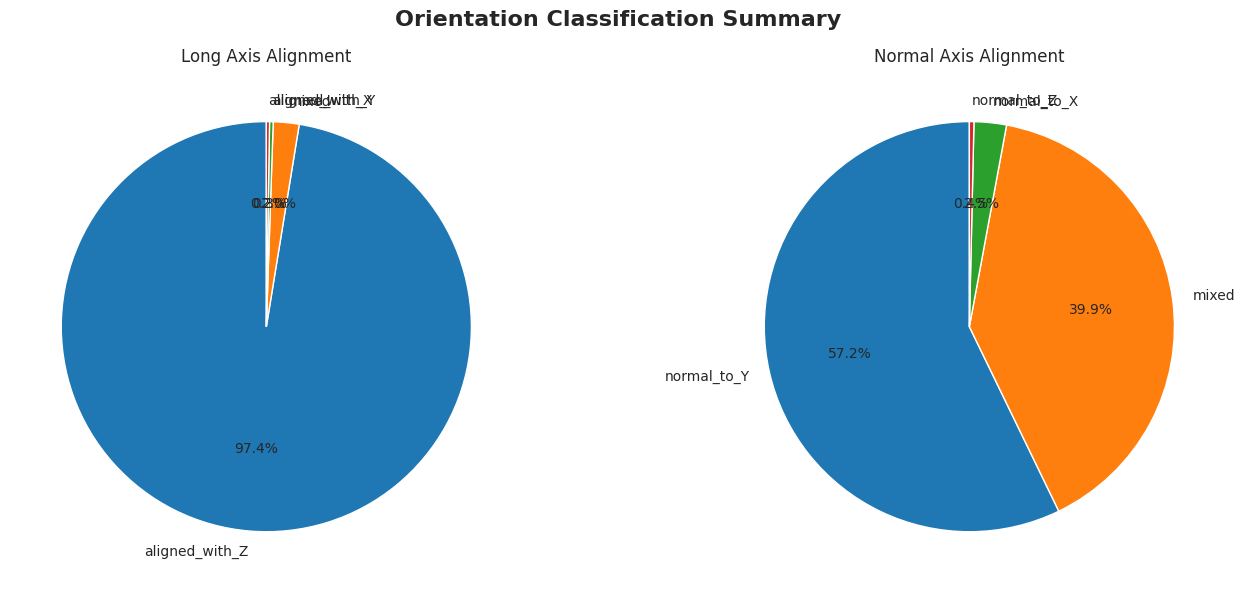

In [13]:
# Define classification criteria
# Example: classify by dominant orientation axis

def classify_long_axis_alignment(row, threshold_deg=30):
    """Classify residue by which global axis its long axis is most aligned with."""
    angles = {
        'X': row['long_angle_x'],
        'Y': row['long_angle_y'],
        'Z': row['long_angle_z']
    }
    min_axis = min(angles, key=angles.get)
    min_angle = angles[min_axis]
    
    if min_angle < threshold_deg:
        return f'aligned_with_{min_axis}'
    else:
        return 'mixed'

def classify_normal_axis_alignment(row, threshold_deg=30):
    """Classify residue by which global axis its normal is most aligned with."""
    angles = {
        'X': row['normal_angle_x'],
        'Y': row['normal_angle_y'],
        'Z': row['normal_angle_z']
    }
    min_axis = min(angles, key=angles.get)
    min_angle = angles[min_axis]
    
    if min_angle < threshold_deg:
        return f'normal_to_{min_axis}'
    else:
        return 'mixed'

# Apply classifications
df['long_axis_class'] = df.apply(classify_long_axis_alignment, axis=1)
df['normal_axis_class'] = df.apply(classify_normal_axis_alignment, axis=1)

# Summary statistics
print("\nLong Axis Classification:")
print(df['long_axis_class'].value_counts())
print(f"\nPercentages:")
print(df['long_axis_class'].value_counts(normalize=True) * 100)

print("\n" + "-"*80)
print("Normal Axis Classification:")
print(df['normal_axis_class'].value_counts())
print(f"\nPercentages:")
print(df['normal_axis_class'].value_counts(normalize=True) * 100)

# %%
# Visualization 4: Classification Pie Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Orientation Classification Summary', fontsize=16, fontweight='bold')

# Long axis classification
long_counts = df['long_axis_class'].value_counts()
axes[0].pie(long_counts.values, labels=long_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Long Axis Alignment')

# Normal axis classification
normal_counts = df['normal_axis_class'].value_counts()
axes[1].pie(normal_counts.values, labels=normal_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Normal Axis Alignment')

plt.tight_layout()
plt.show()

In [ ]:
# # %%
# """
# ## Step 5: 3D Views Colored by Orientation Classes
# ### 5.1 Long-axis alignment
# """
# import py3Dmol

# # Define a simple color map for long-axis classes
# long_color_map = {
#     'aligned_with_X': 'red',
#     'aligned_with_Y': 'green',
#     'aligned_with_Z': 'blue',
#     'mixed': 'gray'
# }

# print("\n" + "="*80)
# print("3D VIEW: Residues colored by LONG-AXIS alignment")
# print("="*80)

# view_long = py3Dmol.view(width=800, height=600)

# for row in df.itertuples(index=False):
#     cls = row.long_axis_class
#     color = long_color_map.get(cls, 'gray')

#     sphere = {
#         'center': {
#             'x': float(row.com_x),
#             'y': float(row.com_y),
#             'z': float(row.com_z),
#         },
#         'radius': 0.3,
#         'color': color,
#         'alpha': 0.9,
#     }
#     view_long.addSphere(sphere)

# view_long.setBackgroundColor('0xeeeeee')
# view_long.zoomTo()
# view_long.show()

# print("Color legend (long axis):")
# for k, v in long_color_map.items():
#     print(f"  {k:15s} -> {v}")



3D VIEW: Residues colored by LONG-AXIS alignment


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Color legend (long axis):
  aligned_with_X  -> red
  aligned_with_Y  -> green
  aligned_with_Z  -> blue
  mixed           -> gray


In [136]:
# # %%
# """
# ### 5.2 Normal-axis alignment
# """

# # Define a simple color map for normal-axis classes
# normal_color_map = {
#     'normal_to_X': 'red',
#     'normal_to_Y': 'green',
#     'normal_to_Z': 'blue',
#     'mixed': 'gray'
# }

# print("\n" + "="*80)
# print("3D VIEW: Residues colored by NORMAL-AXIS alignment")
# print("="*80)

# view_normal = py3Dmol.view(width=800, height=600)

# for row in df.itertuples(index=False):
#     cls = row.normal_axis_class
#     color = normal_color_map.get(cls, 'gray')

#     sphere = {
#         'center': {
#             'x': float(row.com_x),
#             'y': float(row.com_y),
#             'z': float(row.com_z),
#         },
#         'radius': 0.3,
#         'color': color,
#         'alpha': 0.9,
#     }
#     view_normal.addSphere(sphere)

# view_normal.setBackgroundColor('0xeeeeee')
# view_normal.zoomTo()
# view_normal.show()

# print("Color legend (normal axis):")
# for k, v in normal_color_map.items():
#     print(f"  {k:15s} -> {v}")


In [122]:
# %%
"""
## Step 6 (updated): Grain clustering from orientation (LONG axes)
We cluster residues into 2 grains based on their long-axis orientations,
using nematic embedding so v and -v are equivalent.
"""

import numpy as np
from sklearn.cluster import KMeans

def nematic_embed(vecs: np.ndarray) -> np.ndarray:
    """
    Map unit vectors v (shape: [N,3]) to a nematic embedding in R^6
    so that v and -v become identical.

    X = [vx^2, vy^2, vz^2, 2 vx vy, 2 vx vz, 2 vy vz]
    """
    vx, vy, vz = vecs[:, 0], vecs[:, 1], vecs[:, 2]
    return np.column_stack([
        vx * vx,
        vy * vy,
        vz * vz,
        2.0 * vx * vy,
        2.0 * vx * vz,
        2.0 * vy * vz,
    ])

# === use LONG axis here, not normal ===
long_axes = df[['long_x', 'long_y', 'long_z']].values

# Nematic feature space from long axes
X_nem = nematic_embed(long_axes)

# 2-cluster KMeans in nematic orientation space
kmeans = KMeans(n_clusters=2, random_state=0, n_init=20)
grain_labels = kmeans.fit_predict(X_nem)   # 0 or 1

df['grain_label'] = grain_labels

print("Grain label counts (long-axis based):")
print(df['grain_label'].value_counts())


Grain label counts (long-axis based):
grain_label
0    3125
1    2980
Name: count, dtype: int64


In [135]:
# grain_colors = {0: 'blue', 1: 'green'}
# view_grain = py3Dmol.view(width=800, height=600)
# for row in df.itertuples(index=False):
#     color = grain_colors[row.grain_label]
#     view_grain.addSphere({
#         'center': {'x': float(row.com_x), 'y': float(row.com_y), 'z': float(row.com_z)},
#         'radius': 0.35,
#         'color': color,
#         'alpha': 0.9
#     })
# view_grain.setBackgroundColor('0xffffff')
# view_grain.zoomTo()
# view_grain.show()


In [145]:
# %%
"""
## Step 6b: Grain + GB labels using cos thresholds (step2-style)
"""

import numpy as np
from src.utils import nematic_center_to_director   # same helper as in step2.py

dirs = df[['long_x', 'long_y', 'long_z']].values
dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)

# Directors from KMeans centers in nematic space
g1 = nematic_center_to_director(kmeans.cluster_centers_[0])
g2 = nematic_center_to_director(kmeans.cluster_centers_[1])

# deterministic ordering (same as step2)
if tuple(np.round(g2, 6)) < tuple(np.round(g1, 6)):
    g1, g2 = g2, g1

# absolute cosines for headless alignment
cos1 = np.abs(dirs @ g1)
cos2 = np.abs(dirs @ g2)
maxcos = np.maximum(cos1, cos2)
diff = np.abs(cos1 - cos2)

# thresholds: SAME logic as step2.py
TH_HIGH = 0.98   # or whatever you used there
MARGIN  = 0.08

labels = np.array(["GB"] * len(df), dtype=object)
labels[(cos1 >= TH_HIGH) & (cos1 - cos2 >= MARGIN)] = "grain1"
labels[(cos2 >= TH_HIGH) & (cos2 - cos1 >= MARGIN)] = "grain2"

df['grain_label_step2'] = labels

print("Counts (orientation-based):")
print(df['grain_label_step2'].value_counts())


Counts (orientation-based):
grain_label_step2
grain1    2537
grain2    1832
GB        1736
Name: count, dtype: int64


In [156]:
# %%
import numpy as np

dirs = df[['long_x', 'long_y', 'long_z']].values
dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)

# orientation directors g1, g2 obtained earlier
# g1, g2 are unit vectors already

theta1 = np.degrees(np.arccos(np.clip(np.abs(dirs @ g1), -1, 1)))
theta2 = np.degrees(np.arccos(np.clip(np.abs(dirs @ g2), -1, 1)))

# misorientation for each residue
df['misorient_deg'] = np.minimum(theta1, theta2)
print("\nMisorientation statistics (degrees):")
print(df['misorient_deg'].describe())


Misorientation statistics (degrees):
count    6105.000000
mean       10.293469
std         5.611185
min         0.389196
25%         7.581232
50%         9.704451
75%        11.815655
max        78.297756
Name: misorient_deg, dtype: float64


In [157]:
# %%
# thresholds — choose properly based on real misorientation
THETA_LOW  = 5
THETA_HIGH = 20

df['orient_zone'] = np.where(
    df['misorient_deg'] < THETA_LOW, 'grain',
    np.where(df['misorient_deg'] > THETA_HIGH, 'othergrain', 'transition')
)

print(df['orient_zone'].value_counts())


orient_zone
transition    5517
grain          400
othergrain     188
Name: count, dtype: int64


In [159]:
# %%
from sklearn.neighbors import NearestNeighbors

coords = df[['com_x','com_y','com_z']].values
grain = df['grain_label_step2'].values # 0 or 1

NEIGH_RADIUS = 8.0    # Å
MIX_FRAC     = 0.25   # 25% mixing threshold

nbrs = NearestNeighbors(radius=NEIGH_RADIUS).fit(coords)
neighbors = nbrs.radius_neighbors(coords, return_distance=False)

mix_frac = []
for i, nb in enumerate(neighbors):
    if len(nb) == 0:
        mix_frac.append(0)
        continue

    frac_g1 = np.mean(grain[nb] == 0)
    frac_g2 = np.mean(grain[nb] == 1)

    mix_frac.append(min(frac_g1, frac_g2))  # the minority fraction

df['mix_fraction'] = mix_frac


KeyError: 'grain_label_step2'

## contact plane and misorientation checks

In [134]:
# %% [markdown]
"""
# Contact Planes and Misorientation Analysis
This notebook performs detailed grain boundary analysis using latvec outputs.
"""

# %%
# Import necessary modules
import numpy as np
from pathlib import Path
import sys

# Add src to path if needed
sys.path.append('/home/sgarg/structural_analysis_gb')  # Uncomment and modify if needed

from src.contactplanes import (
    read_grain_vectors,
    assign_abc,
    compute_com_from_gro,
    normalize,
    contactplan
)
from src.misorientation_angle import (
    misorientation_for_group,
    unit
)




In [ ]:
# %% [markdown]
"""
## Configuration: Set Your File Paths
"""

# %%
# ==== MODIFY THESE PATHS ====
g1_gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_01/slab_01_seg04_local80.86_g1.gro"  # Grain 1 .gro file
g2_gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_01/slab_01_seg04_local80.86_g2.gro"  # Grain 2 .gro file

# Option 1: Auto-detect output.txt files (assumes <stem>_latvecs.txt naming)
# g1_txt = None  # Will auto-detect
# g2_txt = None  # Will auto-detect

# Option 2: Manually specify output.txt paths (uncomment to use)
g1_txt = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_01/slab_01_seg04_local80.86_g1_latvecs.txt"
g2_txt = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_01/slab_01_seg04_local80.86_g2_latvecs.txt"

# Symmetry for misorientation (default: triclinic for pentacene)
symmetry_name = "triclinic"  # Options: "triclinic", "monoclinic_b", "orthorhombic", etc.

print(f"Grain 1 GRO: {g1_gro_file}")
print(f"Grain 2 GRO: {g2_gro_file}")
print(f"Symmetry: {symmetry_name}")

Grain 1 GRO: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g1.gro
Grain 2 GRO: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g2.gro
Symmetry: triclinic


In [3]:
"""
## 1. Contact Plane Analysis
"""

# %%
print("="*80)
print("CONTACT PLANE ANALYSIS")
print("="*80)

# Determine latvec output file paths
if g1_txt is None:
    g1_txt = Path(g1_gro_file).with_name(f"{Path(g1_gro_file).stem}_latvecs.txt")
if g2_txt is None:
    g2_txt = Path(g2_gro_file).with_name(f"{Path(g2_gro_file).stem}_latvecs.txt")

print(f"\nGrain 1 latvec file: {g1_txt}")
print(f"Grain 2 latvec file: {g2_txt}")

# Read grain vectors from output.txt files
ff1, ef1 = read_grain_vectors(g1_txt)
ff2, ef2 = read_grain_vectors(g2_txt)

print("\n" + "-"*80)
print("GRAIN 1 - Raw Latvec Vectors")
print("-"*80)
print(f"ff vector: {ff1}")
print(f"ef vector: {ef1}")

print("\n" + "-"*80)
print("GRAIN 2 - Raw Latvec Vectors")
print("-"*80)
print(f"ff vector: {ff2}")
print(f"ef vector: {ef2}")

# Assign a, b, c axes
a1, b1, c1 = assign_abc(ff1, ef1)
a2, b2, c2 = assign_abc(ff2, ef2)

print("\n" + "="*80)
print("GRAIN 1 - Normalized Lattice Axes (a, b, c)")
print("="*80)
print(f"a1 (normalized ff): {a1}")
print(f"b1 (normalized ef): {b1}")
print(f"c1 (a × b):         {c1}")
print(f"\nMagnitudes check:")
print(f"  |a1| = {np.linalg.norm(a1):.6f}")
print(f"  |b1| = {np.linalg.norm(b1):.6f}")
print(f"  |c1| = {np.linalg.norm(c1):.6f}")

print("\n" + "="*80)
print("GRAIN 2 - Normalized Lattice Axes (a, b, c)")
print("="*80)
print(f"a2 (normalized ff): {a2}")
print(f"b2 (normalized ef): {b2}")
print(f"c2 (a × b):         {c2}")
print(f"\nMagnitudes check:")
print(f"  |a2| = {np.linalg.norm(a2):.6f}")
print(f"  |b2| = {np.linalg.norm(b2):.6f}")
print(f"  |c2| = {np.linalg.norm(c2):.6f}")

CONTACT PLANE ANALYSIS

Grain 1 latvec file: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g1_latvecs.txt
Grain 2 latvec file: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g2_latvecs.txt

--------------------------------------------------------------------------------
GRAIN 1 - Raw Latvec Vectors
--------------------------------------------------------------------------------
ff vector: [-0.731087 -0.04657   0.680693]
ef vector: [-0.412071  0.782957  0.466021]

--------------------------------------------------------------------------------
GRAIN 2 - Raw Latvec Vectors
--------------------------------------------------------------------------------
ff vector: [-0.987355 -0.079759  0.136997]
ef vector: [-0.528447  0.840277 -0.121156]

GRAIN 1 - Normalized Lattice Axes (a, b, c)
a1 (normalized ff): [-0.73108703 -0.04657     0.68069302]
b1 (normalized ef): [-0.41207105  0.7829571   0.46602106]
c1 (a × b):         [-0.68208423  0.07404

In [4]:
# %%
# Compute centers of mass and contact vector
com1 = compute_com_from_gro(g1_gro_file)
com2 = compute_com_from_gro(g2_gro_file)

print("\n" + "="*80)
print("CENTER OF MASS & CONTACT VECTOR")
print("="*80)
print(f"\nGrain 1 COM: {com1}")
print(f"Grain 2 COM: {com2}")

conn_vec = com2 - com1
contact_vec = normalize(conn_vec)

print(f"\nConnection vector (COM2 - COM1): {conn_vec}")
print(f"Distance between COMs: {np.linalg.norm(conn_vec):.4f} Å")
print(f"\nNormalized contact vector: {contact_vec}")
print(f"Magnitude check: {np.linalg.norm(contact_vec):.6f}")


CENTER OF MASS & CONTACT VECTOR

Grain 1 COM: [91.46132198 97.79491779 85.28114454]
Grain 2 COM: [82.21752114 37.7540736  87.30044833]

Connection vector (COM2 - COM1): [ -9.24380084 -60.04084419   2.0193038 ]
Distance between COMs: 60.7818 Å

Normalized contact vector: [-0.1520817  -0.98780942  0.03322217]
Magnitude check: 1.000000


In [5]:
# Analyze contact vector alignment with Grain 1 axes
print("\n" + "="*80)
print("GRAIN 1 - Contact Vector Alignment Analysis")
print("="*80)

# Dot products with axes
dot_a1 = np.dot(contact_vec, a1)
dot_b1 = np.dot(contact_vec, b1)
dot_c1 = np.dot(contact_vec, c1)

print(f"\nDot products with axes:")
print(f"  contact_vec · a1 = {dot_a1:+.6f}")
print(f"  contact_vec · b1 = {dot_b1:+.6f}")
print(f"  contact_vec · c1 = {dot_c1:+.6f}")

# Angles with axes
angle_a1 = np.degrees(np.arccos(np.clip(np.abs(dot_a1), -1, 1)))
angle_b1 = np.degrees(np.arccos(np.clip(np.abs(dot_b1), -1, 1)))
angle_c1 = np.degrees(np.arccos(np.clip(np.abs(dot_c1), -1, 1)))

print(f"\nAngles with axes:")
print(f"  angle with a1: {angle_a1:.2f}°")
print(f"  angle with b1: {angle_b1:.2f}°")
print(f"  angle with c1: {angle_c1:.2f}°")

# Determine closest axis
angles_g1 = {'a': angle_a1, 'b': angle_b1, 'c': angle_c1}
closest_axis_g1 = min(angles_g1, key=angles_g1.get)
print(f"\n>>> Contact vector is most aligned with axis '{closest_axis_g1}' (angle: {angles_g1[closest_axis_g1]:.2f}°)")

# Contact plane determination for Grain 1
g1_plane = contactplan(a1, b1, c1, contact_vec)
print(f"\n>>> GRAIN 1 CONTACT PLANE: {g1_plane.upper()}")



GRAIN 1 - Contact Vector Alignment Analysis

Dot products with axes:
  contact_vec · a1 = +0.179801
  contact_vec · b1 = -0.695262
  contact_vec · c1 = +0.006425

Angles with axes:
  angle with a1: 79.64°
  angle with b1: 45.95°
  angle with c1: 89.63°

>>> Contact vector is most aligned with axis 'b' (angle: 45.95°)

>>> GRAIN 1 CONTACT PLANE: AC


In [6]:
# Analyze contact vector alignment with Grain 2 axes
print("\n" + "="*80)
print("GRAIN 2 - Contact Vector Alignment Analysis")
print("="*80)

# Dot products with axes
dot_a2 = np.dot(contact_vec, a2)
dot_b2 = np.dot(contact_vec, b2)
dot_c2 = np.dot(contact_vec, c2)

print(f"\nDot products with axes:")
print(f"  contact_vec · a2 = {dot_a2:+.6f}")
print(f"  contact_vec · b2 = {dot_b2:+.6f}")
print(f"  contact_vec · c2 = {dot_c2:+.6f}")

# Angles with axes
angle_a2 = np.degrees(np.arccos(np.clip(np.abs(dot_a2), -1, 1)))
angle_b2 = np.degrees(np.arccos(np.clip(np.abs(dot_b2), -1, 1)))
angle_c2 = np.degrees(np.arccos(np.clip(np.abs(dot_c2), -1, 1)))

print(f"\nAngles with axes:")
print(f"  angle with a2: {angle_a2:.2f}°")
print(f"  angle with b2: {angle_b2:.2f}°")
print(f"  angle with c2: {angle_c2:.2f}°")

# Determine closest axis
angles_g2 = {'a': angle_a2, 'b': angle_b2, 'c': angle_c2}
closest_axis_g2 = min(angles_g2, key=angles_g2.get)
print(f"\n>>> Contact vector is most aligned with axis '{closest_axis_g2}' (angle: {angles_g2[closest_axis_g2]:.2f}°)")

# Contact plane determination for Grain 2
g2_plane = contactplan(a2, b2, c2, contact_vec)
print(f"\n>>> GRAIN 2 CONTACT PLANE: {g2_plane.upper()}")

# %%
# Summary of contact plane analysis
print("\n" + "="*80)
print("CONTACT PLANE ANALYSIS SUMMARY")
print("="*80)
print(f"\nGrain 1 contact plane: {g1_plane.upper()}")
print(f"Grain 2 contact plane: {g2_plane.upper()}")
print(f"\nContact plane pair: {g1_plane}-{g2_plane}")
print(f"\nContact vector points from Grain 1 → Grain 2")
print(f"  Most aligned with Grain 1 axis: {closest_axis_g1} ({angles_g1[closest_axis_g1]:.2f}°)")
print(f"  Most aligned with Grain 2 axis: {closest_axis_g2} ({angles_g2[closest_axis_g2]:.2f}°)")



GRAIN 2 - Contact Vector Alignment Analysis

Dot products with axes:
  contact_vec · a2 = +0.233497
  contact_vec · b2 = -0.753691
  contact_vec · c2 = +0.196632

Angles with axes:
  angle with a2: 76.50°
  angle with b2: 41.09°
  angle with c2: 78.66°

>>> Contact vector is most aligned with axis 'b' (angle: 41.09°)

>>> GRAIN 2 CONTACT PLANE: AC

CONTACT PLANE ANALYSIS SUMMARY

Grain 1 contact plane: AC
Grain 2 contact plane: AC

Contact plane pair: ac-ac

Contact vector points from Grain 1 → Grain 2
  Most aligned with Grain 1 axis: b (45.95°)
  Most aligned with Grain 2 axis: b (41.09°)


In [7]:
"""
## 2. Misorientation Analysis
"""

# %%
print("\n\n" + "="*80)
print("MISORIENTATION ANALYSIS")
print("="*80)

# GB normal is the same as contact vector
gb_normal = contact_vec

print(f"\nGB Normal (same as contact vector): {gb_normal}")
print(f"Magnitude check: {np.linalg.norm(gb_normal):.6f}")

# %%
# Grain frames for misorientation
print("\n" + "-"*80)
print("Grain Frames (for misorientation calculation)")
print("-"*80)

print("\nGrain 1 frame matrix (columns = a1, b1, c1):")
g1_frame = np.column_stack([a1, b1, c1])
print(g1_frame)
print(f"Determinant: {np.linalg.det(g1_frame):.6f}")

print("\nGrain 2 frame matrix (columns = a2, b2, c2):")
g2_frame = np.column_stack([a2, b2, c2])
print(g2_frame)
print(f"Determinant: {np.linalg.det(g2_frame):.6f}")

# %%
# GB normal alignment with Grain 1 axes
print("\n" + "="*80)
print("GB NORMAL ALIGNMENT - GRAIN 1")
print("="*80)

print(f"\nDot products with Grain 1 axes:")
print(f"  GB_normal · a1 = {dot_a1:+.6f}  (angle: {angle_a1:.2f}°)")
print(f"  GB_normal · b1 = {dot_b1:+.6f}  (angle: {angle_b1:.2f}°)")
print(f"  GB_normal · c1 = {dot_c1:+.6f}  (angle: {angle_c1:.2f}°)")
print(f"\n>>> GB normal is most aligned with Grain 1 axis '{closest_axis_g1}' ({angles_g1[closest_axis_g1]:.2f}°)")

print("\n" + "="*80)
print("GB NORMAL ALIGNMENT - GRAIN 2")
print("="*80)

print(f"\nDot products with Grain 2 axes:")
print(f"  GB_normal · a2 = {dot_a2:+.6f}  (angle: {angle_a2:.2f}°)")
print(f"  GB_normal · b2 = {dot_b2:+.6f}  (angle: {angle_b2:.2f}°)")
print(f"  GB_normal · c2 = {dot_c2:+.6f}  (angle: {angle_c2:.2f}°)")
print(f"\n>>> GB normal is most aligned with Grain 2 axis '{closest_axis_g2}' ({angles_g2[closest_axis_g2]:.2f}°)")



MISORIENTATION ANALYSIS

GB Normal (same as contact vector): [-0.1520817  -0.98780942  0.03322217]
Magnitude check: 1.000000

--------------------------------------------------------------------------------
Grain Frames (for misorientation calculation)
--------------------------------------------------------------------------------

Grain 1 frame matrix (columns = a1, b1, c1):
[[-0.73108703 -0.41207105 -0.68208423]
 [-0.04657     0.7829571   0.07404042]
 [ 0.68069302  0.46602106 -0.72751571]]
Determinant: 0.813178

Grain 2 frame matrix (columns = a2, b2, c2):
[[-0.98735521 -0.52844688 -0.11731201]
 [-0.07975902  0.84027681 -0.21361546]
 [ 0.13699703 -0.12115597 -0.96984861]]
Determinant: 0.898903

GB NORMAL ALIGNMENT - GRAIN 1

Dot products with Grain 1 axes:
  GB_normal · a1 = +0.179801  (angle: 79.64°)
  GB_normal · b1 = -0.695262  (angle: 45.95°)
  GB_normal · c1 = +0.006425  (angle: 89.63°)

>>> GB normal is most aligned with Grain 1 axis 'b' (45.95°)

GB NORMAL ALIGNMENT - GRAIN

In [8]:
# Compute misorientation using the high-level function
print("\n" + "="*80)
print("COMPUTING MISORIENTATION (using orix)")
print("="*80)
print(f"Symmetry: {symmetry_name}")

try:
    miso = misorientation_for_group(
        g1_gro_file=g1_gro_file,
        g2_gro_file=g2_gro_file,
        g1_txt=g1_txt,
        g2_txt=g2_txt,
        symmetry_name=symmetry_name
    )
    
    print("\n" + "="*80)
    print("MISORIENTATION RESULTS")
    print("="*80)
    
    if miso['theta_deg'] is not None:
        print(f"\n✓ Misorientation angle (Θ):  {miso['theta_deg']:.4f}°")
        print(f"✓ Twist component:           {miso['twist_deg']:.4f}°")
        print(f"✓ Tilt component:            {miso['tilt_deg']:.4f}°")
        
        if miso['axis'] is not None:
            print(f"\nMisorientation axis (unit vector): {miso['axis']}")
            print(f"Axis magnitude check: {np.linalg.norm(miso['axis']):.6f}")
            
            # Analyze misorientation axis alignment
            axis_dot_gb = np.dot(miso['axis'], gb_normal)
            axis_angle_gb = np.degrees(np.arccos(np.clip(np.abs(axis_dot_gb), -1, 1)))
            print(f"\nMisorientation axis alignment with GB normal:")
            print(f"  axis · GB_normal = {axis_dot_gb:+.6f}")
            print(f"  angle = {axis_angle_gb:.2f}°")
        
        print(f"\nMethod used: {miso['method']}")
        
        # Verification
        if miso['twist_deg'] is not None and miso['tilt_deg'] is not None:
            reconstructed = np.sqrt(miso['twist_deg']**2 + miso['tilt_deg']**2)
            print(f"\nVerification: √(twist² + tilt²) = {reconstructed:.4f}°")
            print(f"              (should ≈ Θ = {miso['theta_deg']:.4f}°)")
            print(f"              Difference: {abs(reconstructed - miso['theta_deg']):.6f}°")
    else:
        print("\n⚠ Misorientation could not be computed.")
        print("  Check that orix is installed: pip install orix")
        
except Exception as e:
    print(f"\n❌ Error computing misorientation: {e}")
    import traceback
    traceback.print_exc()



COMPUTING MISORIENTATION (using orix)
Symmetry: triclinic

MISORIENTATION RESULTS

✓ Misorientation angle (Θ):  40.0262°
✓ Twist component:           38.4073°
✓ Tilt component:            11.2684°

Misorientation axis (unit vector): [-0.41173434 -0.90418123  0.11371518]
Axis magnitude check: 1.000000

Misorientation axis alignment with GB normal:
  axis · GB_normal = +0.959554
  angle = 16.35°

Method used: orix

Verification: √(twist² + tilt²) = 40.0262°
              (should ≈ Θ = 40.0262°)
              Difference: 0.000000°


In [9]:
# %% 
# ======================================================================
#   MISORIENTATION AXIS ALIGNMENT ANALYSIS 
# ======================================================================

if 'miso' in locals() and miso['axis'] is not None:
    mis_axis = miso['axis']   # unit vector

    print("\n" + "="*80)
    print("MISORIENTATION AXIS ALIGNMENT WITH GRAIN 1, GRAIN 2, & GB NORMAL")
    print("="*80)

    def angle_deg(u, v):
        """Return angle (deg) between two vectors."""
        dp = np.dot(u, v)
        dp = np.clip(dp, -1.0, 1.0)
        return np.degrees(np.arccos(np.abs(dp))), dp

    # -------------------------------
    # Alignment for Grain 1 axes
    # -------------------------------
    ang_a1, dot_a1m = angle_deg(mis_axis, a1)
    ang_b1, dot_b1m = angle_deg(mis_axis, b1)
    ang_c1, dot_c1m = angle_deg(mis_axis, c1)

    print("\nGRAIN 1:")
    print(f"  axis · a1 = {dot_a1m:+.6f}   → angle = {ang_a1:.2f}°")
    print(f"  axis · b1 = {dot_b1m:+.6f}   → angle = {ang_b1:.2f}°")
    print(f"  axis · c1 = {dot_c1m:+.6f}   → angle = {ang_c1:.2f}°")

    # -------------------------------
    # Alignment for Grain 2 axes
    # -------------------------------
    ang_a2, dot_a2m = angle_deg(mis_axis, a2)
    ang_b2, dot_b2m = angle_deg(mis_axis, b2)
    ang_c2, dot_c2m = angle_deg(mis_axis, c2)

    print("\nGRAIN 2:")
    print(f"  axis · a2 = {dot_a2m:+.6f}   → angle = {ang_a2:.2f}°")
    print(f"  axis · b2 = {dot_b2m:+.6f}   → angle = {ang_b2:.2f}°")
    print(f"  axis · c2 = {dot_c2m:+.6f}   → angle = {ang_c2:.2f}°")

    # -------------------------------
    # Alignment with GB normal
    # -------------------------------
    ang_gb, dot_gb = angle_deg(mis_axis, gb_normal)

    print("\nGB NORMAL:")
    print(f"  axis · GB_normal = {dot_gb:+.6f}   → angle = {ang_gb:.2f}°")

    # -------------------------------
    # Summary (closest axis)
    # -------------------------------
    all_angles = {
        "G1_a": ang_a1, "G1_b": ang_b1, "G1_c": ang_c1,
        "G2_a": ang_a2, "G2_b": ang_b2, "G2_c": ang_c2,
        "GB_normal": ang_gb
    }

    closest = min(all_angles, key=all_angles.get)

    print("\n" + "-"*80)
    print(f"Closest alignment: {closest}  (angle = {all_angles[closest]:.2f}°)")
    print("-"*80)

else:
    print("\n⚠ No misorientation axis found, cannot compute alignment.")



MISORIENTATION AXIS ALIGNMENT WITH GRAIN 1, GRAIN 2, & GB NORMAL

GRAIN 1:
  axis · a1 = +0.420526   → angle = 65.13°
  axis · b1 = -0.485278   → angle = 60.97°
  axis · c1 = +0.131162   → angle = 82.46°

GRAIN 2:
  axis · a2 = +0.494223   → angle = 60.38°
  axis · b2 = -0.555960   → angle = 56.22°
  axis · c2 = +0.131162   → angle = 82.46°

GB NORMAL:
  axis · GB_normal = +0.959554   → angle = 16.35°

--------------------------------------------------------------------------------
Closest alignment: GB_normal  (angle = 16.35°)
--------------------------------------------------------------------------------


In [10]:
"""
## Complete Summary
"""

# %%
print("\n\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + " "*25 + "COMPLETE SUMMARY" + " "*37 + "#")
print("#" + " "*78 + "#")
print("#"*80)

print("\n" + "="*80)
print("GRAIN INFORMATION")
print("="*80)
print(f"Grain 1: {g1_gro_file}")
print(f"  Latvec file: {g1_txt}")
print(f"  COM: [{com1[0]:.4f}, {com1[1]:.4f}, {com1[2]:.4f}]")
print(f"  Contact plane: {g1_plane.upper()}")

print(f"\nGrain 2: {g2_gro_file}")
print(f"  Latvec file: {g2_txt}")
print(f"  COM: [{com2[0]:.4f}, {com2[1]:.4f}, {com2[2]:.4f}]")
print(f"  Contact plane: {g2_plane.upper()}")

print("\n" + "="*80)
print("CONTACT ANALYSIS")
print("="*80)
print(f"Contact vector: [{contact_vec[0]:+.6f}, {contact_vec[1]:+.6f}, {contact_vec[2]:+.6f}]")
print(f"Distance between grains: {np.linalg.norm(conn_vec):.4f} Å")
print(f"Contact plane pair: {g1_plane}-{g2_plane}")
print("Contact vector alignment:")
print(f"  → Grain 1: closest to {closest_axis_g1}-axis ({angles_g1[closest_axis_g1]:.2f}°)")
print(f"  → Grain 2: closest to {closest_axis_g2}-axis ({angles_g2[closest_axis_g2]:.2f}°)")

if 'miso' in locals() and miso['theta_deg'] is not None:
    print("\n" + "="*80)
    print("MISORIENTATION RESULTS")
    print("="*80)
    print(f"Symmetry: {symmetry_name}")
    print(f"\nMisorientation angle (Θ): {miso['theta_deg']:.4f}°")
    print(f"Twist component:          {miso['twist_deg']:.4f}°")
    print(f"Tilt component:           {miso['tilt_deg']:.4f}°")
    if miso['axis'] is not None:
        print(f"\nMisorientation axis: [{miso['axis'][0]:+.6f}, {miso['axis'][1]:+.6f}, {miso['axis'][2]:+.6f}]")
        axis_dot_gb = np.dot(miso['axis'], gb_normal)
        axis_angle_gb = np.degrees(np.arccos(np.clip(np.abs(axis_dot_gb), -1, 1)))
        print(f"Axis alignment with GB normal: {axis_angle_gb:.2f}°")

print("\n" + "#"*80)
print("Analysis complete!")
print("#"*80)




################################################################################
#                                                                              #
#                         COMPLETE SUMMARY                                     #
#                                                                              #
################################################################################

GRAIN INFORMATION
Grain 1: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g1.gro
  Latvec file: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g1_latvecs.txt
  COM: [91.4613, 97.7949, 85.2811]
  Contact plane: AC

Grain 2: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g2.gro
  Latvec file: /home/sgarg/structural_analysis_gb/test_b45/slab_01/slab_01_seg02_y67.57_g2_latvecs.txt
  COM: [82.2175, 37.7541, 87.3004]
  Contact plane: AC

CONTACT ANALYSIS
Contact vector: [-0.152082, -0.987809, +0.033222]
Distance be

In [12]:
# %%
# Misorientation axis components in Grain 1 and Grain 2 bases

mis_axis = np.array(miso["axis"])  # ensure np.array

# components in grain-1 basis
coeff_g1 = g1_frame.T @ mis_axis
# components in grain-2 basis
coeff_g2 = g2_frame.T @ mis_axis

print("\nMisorientation axis components in Grain 1 basis (a1,b1,c1):")
print(f"  n = {coeff_g1[0]:+.3f} a1  + {coeff_g1[1]:+.3f} b1  + {coeff_g1[2]:+.3f} c1")

print("\nMisorientation axis components in Grain 2 basis (a2,b2,c2):")
print(f"  n = {coeff_g2[0]:+.3f} a2  + {coeff_g2[1]:+.3f} b2  + {coeff_g2[2]:+.3f} c2")



Misorientation axis components in Grain 1 basis (a1,b1,c1):
  n = +0.421 a1  + -0.485 b1  + +0.131 c1

Misorientation axis components in Grain 2 basis (a2,b2,c2):
  n = +0.494 a2  + -0.556 b2  + +0.131 c2


In [4]:
# %%
"""
Twist / Tilt classification using GB.gro

Inputs:
  - Grain1: g1_gro_file, g1_latvecs.txt
  - Grain2: g2_gro_file, g2_latvecs.txt
  - GB:     gb_gro_file  (residues at the grain boundary)

Steps:
  1) Compute GB normal from GB.gro via PCA.
  2) Read lattice vectors (ff/ef) and build (a,b,c) for each grain.
  3) Compute misorientation (angle + axis) using misorientation_for_group.
  4) Compare misorientation axis with GB normal:
       axis ∥ GB_normal  → twist
       axis ⟂ GB_normal  → tilt
       else              → mixed
"""

import numpy as np
import MDAnalysis as mda
from pathlib import Path
import sys

# -----------------------------------------------------------------------------
# Add your package to the path (modify if installed differently)
# -----------------------------------------------------------------------------
sys.path.append("/home/sgarg/structural_analysis_gb")

from src.contactplanes import (
    read_grain_vectors,
    assign_abc,
    contactplan,
)
from src.misorientation_angle import (
    misorientation_for_group,
)

# -----------------------------------------------------------------------------
# CONFIGURATION: MODIFY THESE PATHS
# -----------------------------------------------------------------------------
g1_gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g1.gro"
g2_gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g2.gro"
gb_gro_file = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_gb.gro"

g1_txt = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g1_latvecs.txt"
g2_txt = "/data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g2_latvecs.txt"

symmetry_name = "triclinic"  # for pentacene

print("Grain 1 GRO:", g1_gro_file)
print("Grain 2 GRO:", g2_gro_file)
print("GB GRO:     ", gb_gro_file)
print("Symmetry:   ", symmetry_name)

# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------
def angle_deg(u: np.ndarray, v: np.ndarray) -> float:
    """Return angle (deg) between two vectors, using |dot| to ignore sign."""
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    dp = float(np.dot(u, v))
    dp = np.clip(dp, -1.0, 1.0)
    return float(np.degrees(np.arccos(abs(dp))))

def pca_gb_normal_from_gro(gb_gro: str) -> np.ndarray:
    """
    Compute GB normal from a GB.gro file using PCA on COMs of GB residues.

    Returns:
      gb_normal : unit vector, lying in the slab plane and normal to GB line.
    """
    u = mda.Universe(gb_gro)
    coms = np.array([res.atoms.center_of_mass() for res in u.residues])

    if coms.shape[0] < 3:
        raise ValueError("Not enough GB residues in GB.gro to define a plane.")

    # Center and covariance
    ctr = coms.mean(axis=0)
    X = coms - ctr
    cov = np.cov(X.T)

    # Eigen-decomposition: columns of vecs are eigenvectors, vals ascending
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)
    vecs = vecs[:, order]

    v0 = vecs[:, 0]  # smallest variance → slab normal candidate
    v1 = vecs[:, 1]  # GB-normal candidate (in-plane)
    v2 = vecs[:, 2]  # GB tangent candidate

    # Normalize
    n_slab = v0 / np.linalg.norm(v0)
    n_gb_raw = v1 / np.linalg.norm(v1)

    # Enforce n_gb in slab plane (orthogonal to n_slab)
    n_gb = n_gb_raw - np.dot(n_gb_raw, n_slab) * n_slab
    n_gb /= np.linalg.norm(n_gb)

    # Tangent along GB
    t = np.cross(n_slab, n_gb)
    t /= np.linalg.norm(t)

    print("\n[GB frame from GB.gro] (lab coordinates)")
    print(f"  n_slab (slab normal)     = {np.round(n_slab, 4)}")
    print(f"  n_gb   (GB normal)       = {np.round(n_gb,   4)}")
    print(f"  t      (along GB)        = {np.round(t,      4)}")

    return n_gb


# -----------------------------------------------------------------------------
# 1) GB normal from GB.gro
# -----------------------------------------------------------------------------
gb_normal = pca_gb_normal_from_gro(gb_gro_file)
gb_normal = gb_normal / np.linalg.norm(gb_normal)

print("\nNormalized GB normal:", gb_normal)
print("Magnitude:", np.linalg.norm(gb_normal))

# -----------------------------------------------------------------------------
# 2) Lattice axes (a,b,c) for each grain from latvecs
# -----------------------------------------------------------------------------
ff1, ef1 = read_grain_vectors(g1_txt)
ff2, ef2 = read_grain_vectors(g2_txt)

a1, b1, c1 = assign_abc(ff1, ef1)
a2, b2, c2 = assign_abc(ff2, ef2)

print("\n" + "="*80)
print("LATTICE AXES (normalized)")
print("="*80)
print("\nGrain 1 (a1,b1,c1):")
print("  a1 =", a1)
print("  b1 =", b1)
print("  c1 =", c1)
print("\nGrain 2 (a2,b2,c2):")
print("  a2 =", a2)
print("  b2 =", b2)
print("  c2 =", c2)

# Optional: contact planes using GB normal
g1_plane = contactplan(a1, b1, c1, gb_normal)
g2_plane = contactplan(a2, b2, c2, gb_normal)

print("\n" + "="*80)
print("CONTACT PLANES (using GB normal)")
print("="*80)
print(f"Grain 1 contact plane: {g1_plane.upper()}")
print(f"Grain 2 contact plane: {g2_plane.upper()}")
print(f"Contact plane pair:    {g1_plane}-{g2_plane}")

# -----------------------------------------------------------------------------
# 3) Misorientation (angle + axis) using your existing helper
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("MISORIENTATION (using orix)")
print("="*80)

miso = misorientation_for_group(
    g1_gro_file=g1_gro_file,
    g2_gro_file=g2_gro_file,
    g1_txt=g1_txt,
    g2_txt=g2_txt,
    symmetry_name=symmetry_name,
)

if miso["theta_deg"] is None or miso["axis"] is None:
    print("\n⚠ Misorientation could not be computed. Check orix installation / inputs.")
else:
    theta = miso["theta_deg"]
    twist = miso["twist_deg"]
    tilt  = miso["tilt_deg"]
    axis  = miso["axis"] / np.linalg.norm(miso["axis"])

    print(f"\nTotal misorientation angle Θ: {theta:.3f}°")
    print(f"Twist component:             {twist:.3f}°")
    print(f"Tilt component:              {tilt:.3f}°")
    print(f"Misorientation axis:         {axis} (|axis|={np.linalg.norm(axis):.4f})")

    # -----------------------------------------------------------------------------
    # 4) Alignment between misorientation axis and GB normal → twist / tilt / mixed
    # -----------------------------------------------------------------------------
    ang_axis_gb = angle_deg(axis, gb_normal)
    dot_axis_gb = float(np.dot(axis / np.linalg.norm(axis),
                               gb_normal / np.linalg.norm(gb_normal)))

    print("\n" + "="*80)
    print("MISORIENTATION AXIS vs GB NORMAL")
    print("="*80)
    print(f"axis · GB_normal = {dot_axis_gb:+.6f}")
    print(f"angle(axis, GB_normal) = {ang_axis_gb:.2f}°")

    # Simple classification
    if ang_axis_gb < 10.0:
        gb_type = "TWIST"
    elif 80.0 < ang_axis_gb < 100.0:
        gb_type = "TILT"
    else:
        gb_type = "MIXED"

    print(f"\n⇒ Classified as: {gb_type} boundary (based on axis–GB_normal angle).")

    # Optional consistency check with twist/tilt components
    recon = np.sqrt(twist**2 + tilt**2)
    print("\nCheck: √(twist² + tilt²) = "
          f"{recon:.3f}°  (should ≈ Θ = {theta:.3f}°, Δ={abs(recon-theta):.3f}°)")


Grain 1 GRO: /data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g1.gro
Grain 2 GRO: /data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_g2.gro
GB GRO:      /data/sgarg/pentacene/gb_pen_schellhammer/final_working_str/structural_analysis_GB/2_new_b45/slab_07/slab_07_seg01_local129.36_gb.gro
Symmetry:    triclinic

[GB frame from GB.gro] (lab coordinates)
  n_slab (slab normal)     = [0.0851 0.5453 0.8339]
  n_gb   (GB normal)       = [ 0.6362  0.6144 -0.4667]
  t      (along GB)        = [-0.7668  0.5702 -0.2946]

Normalized GB normal: [ 0.63616574  0.6143939  -0.46670471]
Magnitude: 1.0

LATTICE AXES (normalized)

Grain 1 (a1,b1,c1):
  a1 = [-0.71536313 -0.03201401  0.69801912]
  b1 = [-0.3984081   0.7791122   0.48399913]
  c1 = [-0.69779543  0.08500678 -0.71123511]

Grain 2 (a2,b2,c2):
  a2 = [-0.99833554  0.04787698 -0.03215499]
  b2 = 